## Import des modules

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Analyse Exploratoire

## 1.1 Import et observation des données

In [70]:
building_consumption = pd.read_csv("Data/2016_Building_Energy_Benchmarking.csv")

## 1.2 On regarde comment un batiment est défini dans ce jeu de données

In [71]:
building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,"98,101.000",0659000030,...,"1,156,514.250","3,946,027.000","12,764.529","1,276,453.000",False,NaN,Compliant,NaN,249.980,2.830
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,"98,101.000",0659000220,...,"950,425.188","3,242,851.000","51,450.816","5,145,082.000",False,NaN,Compliant,NaN,295.860,2.860
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,"98,101.000",0659000475,...,"14,515,435.000","49,526,664.000","14,938.000","1,493,800.000",False,NaN,Compliant,NaN,"2,089.280",2.190
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,"98,101.000",0659000640,...,"811,525.312","2,768,924.000","18,112.131","1,811,213.000",False,NaN,Compliant,NaN,286.430,4.670
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,"98,121.000",0659000970,...,"1,573,448.625","5,368,607.000","88,039.984","8,803,998.000",False,NaN,Compliant,NaN,505.010,2.880


On regarde le nombre de valeurs manquantes par colonne ainsi que leur type

In [72]:
building_consumption.info()

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   str    
 3   PrimaryPropertyType              3376 non-null   str    
 4   PropertyName                     3376 non-null   str    
 5   Address                          3376 non-null   str    
 6   City                             3376 non-null   str    
 7   State                            3376 non-null   str    
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   str    
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   str    
 12  Latitude                       

#### TERMINER L'ANALYSE EXPLORATOIRE

A réaliser :
- Une analyse descriptive des données, y compris une explication du sens des colonnes gardées, des arguments derrière la suppression de lignes ou de colonnes, des statistiques descriptives et des visualisations pertinentes.

Qelques pistes d'analyse :

* Identifier les colonnes avec une majorité de valeurs manquantes ou constantes en utilisant la méthode value_counts() de Pandas
* Mettre en evidence les différences entre les immeubles mono et multi-usages
* Utiliser des pairplots et des boxplots pour faire ressortir les outliers ou des batiments avec des valeurs peu cohérentes d'un point de vue métier

## 1.3 Restriction au périmètre non résidentiel et statistiques des données brutes (avant nettoyage)

In [73]:
# On vérifie et on stocke le nombre de lignes de départ pour rappel
nb_lignes_initial = building_consumption.shape[0]
print(f"Nombre de bâtiments avant filtrage : {nb_lignes_initial}")

# Voir les types dispo dans BuildingTypes
print(building_consumption["BuildingType"].value_counts())

Nombre de bâtiments avant filtrage : 3376
BuildingType
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64


In [74]:
# Je conserve uniquement ceux qui ne commencent PAS par Multifamily car il me semble que ce sont eux
# qui sont les batiments résidentiels
building_consumption = building_consumption[~building_consumption["BuildingType"].str.contains("Multifamily")]

# On voit donc l'écart
nb_lignes_apres_filtrage = building_consumption.shape[0]
print(f"Nombre de bâtiments après filtrage résidentiel : {nb_lignes_apres_filtrage}")
print(f"Lignes supprimées : {nb_lignes_initial - nb_lignes_apres_filtrage}")

Nombre de bâtiments après filtrage résidentiel : 1668
Lignes supprimées : 1708


**Statistiques descriptives des données brutes (avant nettoyage)**
On décrit d'abord le jeu tel qu'il est, pour repérer les valeurs incohérentes

In [75]:
"""Statistiques descriptives AVANT nettoyage (périmètre non résidentiel uniquement)"""
# Mêmes colonnes qu'en 1.8, pour pouvoir comparer avant / après nettoyage
# (la target est écrite en toutes lettres : la variable "target" n'est définie qu'en 1.7)
colonnes_cles_brutes = [
    "PropertyGFATotal", "PropertyGFABuilding(s)", "PropertyGFAParking",
    "NumberofFloors", "NumberofBuildings", "YearBuilt", "SiteEnergyUse(kBtu)",
]

# .T = une ligne par variable, plus lisible
stats_brutes = building_consumption[colonnes_cles_brutes].describe().T

# Deux colonnes en plus pour repérer les anomalies d'un coup d'oeil :
# - nb_zeros : un bâtiment avec 0 étage ou 0 bâtiment n'a pas de sens physique
# - nb_manquants : describe() ignore les NaN sans prévenir, on les compte à part
stats_brutes["nb_zeros"] = (building_consumption[colonnes_cles_brutes] == 0).sum()
stats_brutes["nb_manquants"] = building_consumption[colonnes_cles_brutes].isnull().sum()

stats_brutes.round(1)

,count,mean,std,min,25%,50%,75%,max,nb_zeros,nb_manquants
PropertyGFATotal,"1,668.000","118,842.700","297,362.200","11,285.000","29,477.800","49,289.500","105,325.000","9,320,156.000",0,0
PropertyGFABuilding(s),"1,668.000","105,944.700","284,211.600","3,636.000","28,475.200","47,391.500","94,759.800","9,320,156.000",0,0
PropertyGFAParking,"1,668.000","12,898.000","42,274.500",0.000,0.000,0.000,0.000,"512,608.000",1335,0
NumberofFloors,"1,668.000",4.100,6.600,0.000,1.000,2.000,4.000,99.000,16,0
NumberofBuildings,"1,666.000",1.200,2.900,0.000,1.000,1.000,1.000,111.000,52,2
YearBuilt,"1,668.000","1,961.900",32.700,"1,900.000","1,930.000","1,965.000","1,989.000","2,015.000",0,0
SiteEnergyUse(kBtu),"1,666.000","8,437,933.200","30,243,803.400",0.000,"1,229,290.800","2,554,947.200","6,913,348.500","873,923,712.000",16,2


In [76]:
# Inspection du bâtiment de 99 étages avant de décider quoi en faire
building_consumption[building_consumption["NumberofFloors"] == 99][
    ["PropertyName", "PrimaryPropertyType", "NumberofFloors", "PropertyGFATotal", "SiteEnergyUse(kBtu)"]
]

,PropertyName,PrimaryPropertyType,NumberofFloors,PropertyGFATotal,SiteEnergyUse(kBtu)
1359,Seattle Chinese Baptist Church,Worship Facility,99,21948,"326,001.188"


**Lecture des statistiques brutes (1 668 bâtiments non résidentiels, avant nettoyage)**

Plusieurs valeurs incohérentes d'un point de vue métier, qui motivent le nettoyage
- **16 bâtiments à 0 étage** et **52 à 0 bâtiment** : physiquement impossible pour un bâtiment mesuré.
- **16 bâtiments à 0 kBtu de consommation** et 2 sans valeur : un bâtiment non résidentiel en activité consomme forcément de l'énergie.
- **Valeurs extrêmes** : une surface de 9,3 M sqft et une consommation de 874 M kBtu, qu'on retrouvera (ou non) après le filtre de conformité.
- **`PropertyGFAParking` à 0 pour 1 335 bâtiments (80 %)** : ce n'est pas une anomalie, ces bâtiments n'ont simplement pas de parking.

**Cas isolé repéré : un bâtiment de 99 étages** (Seattle Chinese Baptist Church, 21 948 sqft), soit environ 20 m² par étage : erreur de saisie certaine sur le nombre d'étages.  
Après vérification sur internet, le plus haut batiment de Seattle est à 76 étages.  
Le reste de la ligne (surface, consommation, type) est cohérent

## 1.4 Suppression des colonnes sans valeur ajoutée

In [77]:
# On construit un tableau récapitulatif : une ligne par colonne du dataset
resume_colonnes = pd.DataFrame({
    "type": building_consumption.dtypes,
    "nb_valeurs_uniques": building_consumption.nunique(),
    "nb_lignes": len(building_consumption),
    "nb_manquants": building_consumption.isnull().sum(),
})

# Colonne pratique : le ratio "tx_valeurs_uniques"
# proche de 1.0 -> beaucoup de valeurs différentes
# proche de 0.0 -> peu de valeurs différentes, très similaires
resume_colonnes["tx_valeurs_uniques"] = (resume_colonnes["nb_valeurs_uniques"] / resume_colonnes["nb_lignes"]).round(3)

# Tri du plus pour repérer d'un coup d'oeil les colonnes qui ont beaucoup de valeurs uniques
resume_colonnes = resume_colonnes.sort_values("tx_valeurs_uniques", ascending=False)

resume_colonnes

,type,nb_valeurs_uniques,nb_lignes,nb_manquants,tx_valeurs_uniques
OSEBuildingID,int64,1668,1668,0,1.000
PropertyName,str,1664,1668,0,0.998
Electricity(kWh),float64,1655,1668,2,0.992
Electricity(kBtu),float64,1655,1668,2,0.992
SiteEnergyUse(kBtu),float64,1651,1668,2,0.990
Address,str,1647,1668,0,0.987
SiteEnergyUseWN(kBtu),float64,1640,1668,3,0.983
TotalGHGEmissions,float64,1594,1668,2,0.956
PropertyGFATotal,int64,1590,1668,0,0.953
TaxParcelIdentificationNumber,str,1587,1668,0,0.951


La colonne `YearsENERGYSTARCertified` ne semble pas très utile, surtout qu'on a pas mal de formats de date disparates dedans  
La colonne `Comments` est vide  
Les colonnes `City`, `State` et `DataYear` ne sont pas non plus pertinentes, et contiennent quasiment toujours la même donnée  
Même chose pour `OSEBuildingID`, `Address`, `TaxParcelIdentificationNumber`  
Pour information, je conserve la colone `PropertyName` car je pense qu'elle pourra être utile plus tard pour identifier les fonctions du batiment

In [78]:
building_consumption = building_consumption.drop(columns=["Comments", "YearsENERGYSTARCertified", "City", "State", "DataYear", "OSEBuildingID", "Address", "TaxParcelIdentificationNumber"])


## 1.5 Gestion des valeurs manquantes, conversions en numériques, normalisation, retrait de lignes inutiles

In [79]:
# On regarde aussi s'il y a des colonnes avec beaucoup de NaN
# C'est directement exprimé en pourcentage pour essayer de comprendre par la suite pourquoi certaines ont beaucoup de NaN
taux_manquants = (building_consumption.isnull().sum() / len(building_consumption) * 100).sort_values(ascending=False)
print(taux_manquants[taux_manquants > 0])

Outlier                           98.981
ThirdLargestPropertyUseType       78.837
ThirdLargestPropertyUseTypeGFA    78.837
SecondLargestPropertyUseTypeGFA   48.741
SecondLargestPropertyUseType      48.741
ENERGYSTARScore                   34.412
ZipCode                            0.959
LargestPropertyUseTypeGFA          0.360
LargestPropertyUseType             0.360
SiteEUIWN(kBtu/sf)                 0.180
SiteEUI(kBtu/sf)                   0.180
SiteEnergyUseWN(kBtu)              0.180
GHGEmissionsIntensity              0.120
NaturalGas(therms)                 0.120
Electricity(kWh)                   0.120
Electricity(kBtu)                  0.120
NaturalGas(kBtu)                   0.120
SourceEUIWN(kBtu/sf)               0.120
ListOfAllPropertyUseTypes          0.120
SteamUse(kBtu)                     0.120
SiteEnergyUse(kBtu)                0.120
NumberofBuildings                  0.120
SourceEUI(kBtu/sf)                 0.120
TotalGHGEmissions                  0.120
dtype: float64


In [80]:
# Pour éviter les conflits futurs, je remplace les NaN des colonnes SecondLargestPropertyUseType et ThirdLargestPropertyUseType par du None
# Même principe pour les surfaces affectées à ces usages, mais cette fois on passe en numérique, au cas ou
building_consumption["SecondLargestPropertyUseType"] = building_consumption["SecondLargestPropertyUseType"].fillna("None")
building_consumption["ThirdLargestPropertyUseType"] = building_consumption["ThirdLargestPropertyUseType"].fillna("None")
building_consumption["SecondLargestPropertyUseTypeGFA"] = building_consumption["SecondLargestPropertyUseTypeGFA"].fillna(0)
building_consumption["ThirdLargestPropertyUseTypeGFA"] = building_consumption["ThirdLargestPropertyUseTypeGFA"].fillna(0)

# Normalisation de la casse pour éviter les doublons (ex: "North" et "NORTH" actuellement traités comme 2 quartiers différents)
# Repéré lors du feature engineering car j'avais un plantage
building_consumption["Neighborhood"] = building_consumption["Neighborhood"].str.upper()

# 6 bâtiments sans LargestPropertyUseType/LargestPropertyUseTypeGFA renseignés
# Trop peu de lignes pour justifier une imputation, je retire
nb_avant = building_consumption.shape[0]
building_consumption = building_consumption.dropna(subset=["LargestPropertyUseTypeGFA"])
nb_apres = building_consumption.shape[0]

print(f"Nombre de bâtiments après filtrage des suppressions de NaN : {nb_apres}")
print(f"Lignes supprimées : {nb_avant - nb_apres}")

Nombre de bâtiments après filtrage des suppressions de NaN : 1662
Lignes supprimées : 6


## 1.6 Retrait des données non fiables (`ComplianceStatus`, 0 ou 99 étages, 0 bâtiment)

In [81]:
# La colonne ComplianceStatus semble indiquer aussi lorsque les valeurs semblent incorrectes
# Et donc être présente uniquement pour pouvoir filtrer proprement le jeu de données
# Je filtre donc pour ne conserver que les lignes == Compliant
# Note importante, toutes les colonnes qui sont flaggées "Outlier" sont avec un ComplianceStatus /= Compliant
# Donc ce filtre permet aussi d'isoler les Outliers déjà marqués comme tels, suppression de la colonne Outlier
nb_avant = building_consumption.shape[0]
building_consumption = building_consumption[building_consumption["ComplianceStatus"] == "Compliant"]
building_consumption = building_consumption.drop(columns=["Outlier"])
nb_apres = building_consumption.shape[0]

print(f"Nombre de bâtiments après filtrage des lignes non compliant : {nb_apres}")
print(f"Lignes supprimées : {nb_avant - nb_apres}")

Nombre de bâtiments après filtrage des lignes non compliant : 1544
Lignes supprimées : 118


**Raisonnement pour les batiments 0 Etages**

In [82]:
"""Inspection des bâtiments à 0 étage avant de décider : supprimer ou imputer ?"""
# target pas encore définie (1.7) -> nom de colonne écrit en toutes lettres
batiments_0_etage = building_consumption[building_consumption["NumberofFloors"] == 0]
print(f"Nombre de bâtiments à 0 étage : {len(batiments_0_etage)}")

# Qui sont-ils ? Type, surface, consommation : le reste de la ligne est-il cohérent ?
print(batiments_0_etage[["PropertyName", "PrimaryPropertyType", "PropertyGFATotal", "SiteEnergyUse(kBtu)"]])

# Nombre d'étages médian des bâtiments du MÊME type (hors 0) : c'est la valeur qu'on imputerait
# -> permet de voir si l'imputation par type donnerait des valeurs plausibles
types_concernes = batiments_0_etage["PrimaryPropertyType"].unique()
mediane_par_type = (
    building_consumption[building_consumption["NumberofFloors"] > 0]   # on exclut les 0 du calcul
    .groupby("PrimaryPropertyType")["NumberofFloors"]
    .agg(["median", "count"])        # médiane + nombre de bâtiments servant au calcul (fiabilité)
    .loc[types_concernes]            # on ne garde que les types concernés
)
print(mediane_par_type)

Nombre de bâtiments à 0 étage : 16
                                           PropertyName  \
166                                 Grand Hyatt Seattle   
487                                     Arnold Pavilion   
488                                2200 Westlake - SEDO   
564                                       Pacific Place   
1754                                HART First Hill LLC   
1993  (ID#24086)Campus1:KC Metro Transit Atlantic Ce...   
3130                                       Sandpoint #5   
3131                                      Sandpoint #25   
3132                                      Sandpoint #29   
3168                                           Magnuson   
3273             Smilow Rainier Vista Boys & Girls Club   
3274          University of Washington - Seattle Campus   
3276                                         Cedar Hall   
3278                                        Lander Hall   
3279                                        Mercer Hall   
3280                 

**Bâtiments à 0 étage : supprimer ou imputer ?**

Les 16 bâtiments ont tous passé le filtre de conformité. En les inspectant, ce ne sont pas des petits bâtiments mal saisis, mais surtout :
- des **ensembles multi-bâtiments** saisis comme un seul relevé (campus de l'université de Washington, KC Metro Transit, Magnuson), pour lesquels un « nombre d'étages » n'a pas de sens ;
- de **très grands bâtiments** (Grand Hyatt, Pacific Place : plus de 900 000 sqft).

**Imputation envisagée : la médiane du nombre d'étages par type de bâtiment.** Elle donnerait des valeurs peu crédibles, car la médiane décrit un bâtiment *typique* de son type. Par exemple, le Grand Hyatt recevrait 7 étages, la médiane des hôtels, alors qu'un hôtel de cette taille en compte plusieurs dizaines.

**Décision : suppression.** Ce n'est pas un retrait d'outliers statistiques (traité en 3.3), mais un problème de qualité de donnée :
1. la valeur est fausse (un bâtiment a au moins 1 étage), même si le relevé est déclaré conforme ;
2. elle n'est pas corrigeable de façon crédible : une valeur imputée fausse serait apprise par le modèle comme si elle était vraie ;
3. certains relevés sont hors périmètre : un campus entier n'est pas « un bâtiment ».

16 bâtiments, soit 1 % du jeu. **Limite assumée** : le modèle sera moins fiable pour les très grands ensembles.

In [83]:
# Suppression des 16 bâtiments à 0 étage : décision justifiée
# (campus ou très grands bâtiments, pour lesquels l'imputation par la médiane du type serait peu crédible)
nb_avant = building_consumption.shape[0]
building_consumption = building_consumption[building_consumption["NumberofFloors"] > 0]
nb_apres = building_consumption.shape[0]

print(f"Nombre de bâtiments après filtrage des lignes avec un NumberofFloors = 0 : {nb_apres}")
print(f"Lignes supprimées : {nb_avant - nb_apres}")

Nombre de bâtiments après filtrage des lignes avec un NumberofFloors = 0 : 1528
Lignes supprimées : 16


**Raisonnement pour le batiment avec 99 Etages (`NumberofFloors`)**  
**Comparaison avec les autres lieux dont `PrimaryPropertyType` = Worship Facility**, la médiane est-elle crédible ?

In [84]:
"""Bâtiment de 99 étages : la médiane des lieux de culte ?"""
# Rappel : repéré en 1.3 (Seattle Chinese Baptist Church, Worship Facility, 21 948 sqft, 99 étages)
lieux_de_culte = building_consumption[building_consumption["PrimaryPropertyType"] == "Worship Facility"]

# On exclut l'église en erreur du calcul (sinon elle fausserait elle-même la référence)
autres_lieux_de_culte = lieux_de_culte[lieux_de_culte["NumberofFloors"] < 99]

# Nombre d'étages des autres lieux de culte : la médiane est-elle stable ? sur combien de bâtiments ?
print(autres_lieux_de_culte["NumberofFloors"].describe())

# Surface médiane des lieux de culte, à comparer aux 21 948 sqft de l'église :
# si elle est proche, l'église est un lieu de culte "typique" -> la médiane du type lui convient
print(f"Surface médiane des lieux de culte : {autres_lieux_de_culte['PropertyGFATotal'].median():,.0f} sqft")

count   68.000
mean     1.941
std      0.770
min      1.000
25%      1.000
50%      2.000
75%      2.000
max      5.000
Name: NumberofFloors, dtype: float64
Surface médiane des lieux de culte : 26,370 sqft


In [85]:
"""Imputation du nombre d'étages de l'église par la médiane des lieux de culte"""
# int() : le nombre d'étages est un entier, on évite de mettre 1.5 étage par exemple
mediane_etages_culte = int(autres_lieux_de_culte["NumberofFloors"].median())

# On cible la ligne repérée en 1.3 par sa valeur (99 étages) plutôt que par son numéro de ligne
masque_etages_aberrants = building_consumption["NumberofFloors"] == 99
print(f"Bâtiments corrigés : {masque_etages_aberrants.sum()}")

# .loc[lignes, colonne] = valeur : remplace uniquement la case visée
building_consumption.loc[masque_etages_aberrants, "NumberofFloors"] = mediane_etages_culte

# Vérification : le nouveau maximum doit être nettement inférieur à 99
print(f"Valeur imputée : {mediane_etages_culte} étage(s)")
print(f"Nouveau maximum de NumberofFloors : {building_consumption['NumberofFloors'].max()}")
print(f"Nombre de bâtiments (inchangé, on corrige sans supprimer) : {building_consumption.shape[0]}")

Bâtiments corrigés : 1
Valeur imputée : 2 étage(s)
Nouveau maximum de NumberofFloors : 76
Nombre de bâtiments (inchangé, on corrige sans supprimer) : 1528


**Bâtiment de 99 étages : imputation**

- **La valeur imputée est crédible** : les 68 autres lieux de culte ont entre 1 et 5 étages, avec une médiane de **2 étages** et une dispersion très faible. L'église a une surface (21 948 sqft) proche de la médiane des lieux de culte (26 370 sqft) : c'est un lieu de culte typique, la médiane de son type lui convient.
- **Pourquoi imputer ici, alors qu'on a supprimé les bâtiments à 0 étage ?** Le critère est le même dans les deux cas : *la valeur de remplacement est-elle crédible ?* Pour l'église, oui : erreur isolée sur un bâtiment typique d'un type très homogène. Pour les campus et très grands bâtiments à 0 étage, non.
- **Vérification** : après correction, le maximum est de **76 étages**, soit exactement le nombre d'étages du Columbia Center, plus haut bâtiment de Seattle. Plus aucune valeur impossible.

**Imputation de `NumberofBuildings`**

In [86]:
"""Inspection des bâtiments à 0 bâtiment avant d'imputer : la valeur 1 est-elle crédible ?"""
batiments_0_bat = building_consumption[building_consumption["NumberofBuildings"] == 0]
print(f"Nombre de bâtiments déclarant 0 bâtiment : {len(batiments_0_bat)}")

# Valeur la plus fréquente (mode) chez les autres bâtiments : c'est la valeur qu'on imputerait
autres = building_consumption[building_consumption["NumberofBuildings"] > 0]
print(f"Part des autres relevés avec exactement 1 bâtiment : {(autres['NumberofBuildings'] == 1).mean():.0%}")

# Leur surface ressemble-t-elle à celle des bâtiments uniques, ou plutôt à celle des campus ?
# On compare la surface médiane de 3 groupes
comparaison_surfaces = pd.Series({
    "Déclarent 0 bâtiment": batiments_0_bat["PropertyGFATotal"].median(),
    "Exactement 1 bâtiment": autres.loc[autres["NumberofBuildings"] == 1, "PropertyGFATotal"].median(),
    "Plusieurs bâtiments": autres.loc[autres["NumberofBuildings"] > 1, "PropertyGFATotal"].median(),
})
print(comparaison_surfaces.round(0))

# Types les plus représentés parmi eux
print(batiments_0_bat["PrimaryPropertyType"].value_counts().head(5))

Nombre de bâtiments déclarant 0 bâtiment : 51
Part des autres relevés avec exactement 1 bâtiment : 97%
Déclarent 0 bâtiment    54,863.000
Exactement 1 bâtiment   46,580.000
Plusieurs bâtiments     94,796.000
dtype: float64
PrimaryPropertyType
Other                          13
Small- and Mid-Sized Office    10
Mixed Use Property              5
Large Office                    4
Warehouse                       3
Name: count, dtype: int64


**Bâtiments déclarant 0 bâtiment : imputation par la valeur la plus fréquente (1)**

- 51 relevés déclarent 0 bâtiment, ce qui est impossible pour un bâtiment mesuré.
- **La valeur 1 est crédible pour eux** : 97 % des autres relevés ont exactement 1 bâtiment, et leur surface médiane (54 863 sqft) est proche de celle des bâtiments uniques (46 580 sqft), loin de celle des ensembles multi-bâtiments (94 796 sqft). Ce sont des types courants (bureaux, usage mixte, entrepôts), pas des campus.
- **Décision : imputation par 1**, sans perte de lignes.

In [87]:
# Imputation des 51 bâtiments déclarant 0 bâtiment par la valeur la plus fréquente (1)
# 97 % des relevés ont 1 bâtiment, et la surface de ces 51 bâtiments
# correspond à celle des bâtiments uniques, pas à celle des campus
nb_avant = building_consumption.shape[0]
building_consumption["NumberofBuildings"] = building_consumption["NumberofBuildings"].replace(0, 1)
nb_apres = building_consumption.shape[0]

# Ca n'impacte pas le nombre de lignes
print(f"Nombre de bâtiments après la modif par 1 sur le NumberofBuildings : {nb_apres}")
print(f"Lignes supprimées : {nb_avant - nb_apres}")

Nombre de bâtiments après la modif par 1 sur le NumberofBuildings : 1528
Lignes supprimées : 0


Pour vous inspirer, ou comprendre l'esprit recherché dans une analyse exploratoire, vous pouvez consulter ce notebook en ligne : https://www.kaggle.com/code/pmarcelino/comprehensive-data-exploration-with-python. Il ne s'agit pas d'un modèle à suivre à la lettre ni d'un template d'analyses attendues pour ce projet.

## 1.7 Choix et distribution de la target (brute, puis passage en log)

count         1,528.000
mean      8,204,976.437
std      22,318,095.170
min          57,133.199
25%       1,243,815.438
50%       2,687,720.375
75%       7,243,102.750
max     448,385,312.000
Name: SiteEnergyUse(kBtu), dtype: float64


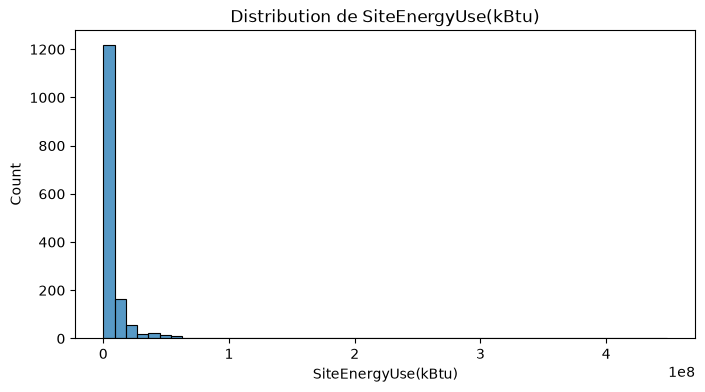

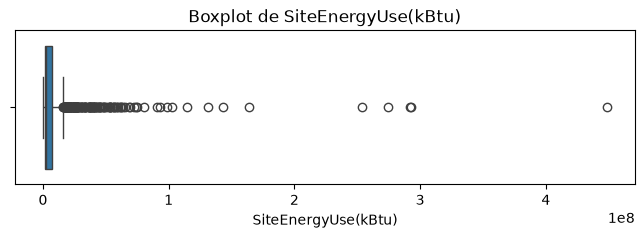

Skewness : 10.749389782229546


In [88]:
# Target pour le reste du projet = SiteEnergyUse
target = "SiteEnergyUse(kBtu)"

# Statistiques descriptives de la target : ça donne l'ordre de grandeur
# (min, max, moyenne, médiane, quartiles...)
print(building_consumption[target].describe())

# Histogramme : pour voir la forme de la distribution
plt.figure(figsize=(8, 4))
sns.histplot(building_consumption[target], bins=50)
plt.title(f"Distribution de {target}")
plt.show()

# Boxplot : complémentaire de l'histogramme
plt.figure(figsize=(8, 2))
sns.boxplot(x=building_consumption[target])
plt.title(f"Boxplot de {target}")
plt.show()

# Skewness
print(f"Skewness : {building_consumption[target].skew()}")

Ces visualisations ne sont pas très parlantes, je passe en Log

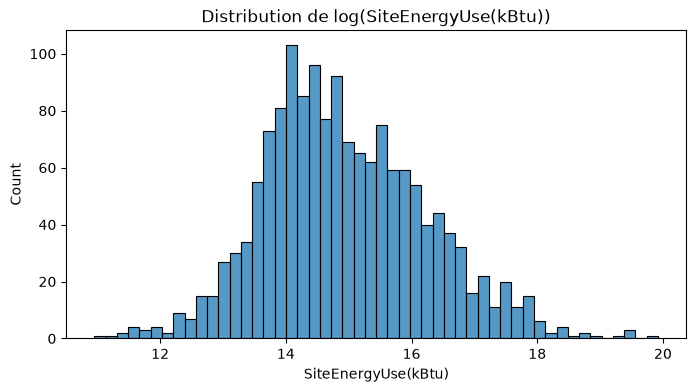

Skewness (log) : 0.35943406598607797


In [89]:
# On visualise la distribution sur une échelle log pour "rapprocher" les petites
# et les grandes valeurs et ainsi mieux voir la vraie forme de la distribution
plt.figure(figsize=(8, 4))
sns.histplot(np.log(building_consumption[target]), bins=50)
plt.title(f"Distribution de log({target})")
plt.show()

# On regarde aussi le skewness sur cette échelle log, pour comparer
print(f"Skewness (log) : {np.log(building_consumption[target]).skew()}")

Beaucoup plus parlant

## 1.8 Statistiques descriptives après nettoyage

In [90]:
"""Statistiques descriptives APRÈS nettoyage (à comparer avec la 1.3)"""
# Mêmes colonnes qu'en 1.3 (on réutilise la liste) pour comparer avant / après sur la même base
# Choix des colonnes : les variables STRUCTURELLES numériques (utilisables par le modèle) + la cible
# Colonnes écartées volontairement :
# - consommations détaillées (électricité, gaz...) : ce sont des morceaux de la cible -> data leakage
# - Latitude / Longitude : des coordonnées, leur moyenne n'a pas de sens
# - ZipCode / CouncilDistrictCode : des codes de zones, pas des quantités
# - surfaces par usage (LargestPropertyUseTypeGFA...) : des sous-parties de la surface totale, redondantes ici
colonnes_cles = colonnes_cles_brutes

# .T = on "retourne" le tableau : une ligne par variable, plus lisible
stats = building_consumption[colonnes_cles].describe().T

# Ratio moyenne / médiane : si > 1, quelques très grandes valeurs tirent la moyenne vers le haut
# -> distribution asymétrique (comme vu pour la cible en 1.7)
stats["ratio_moyenne_mediane"] = (stats["mean"] / stats["50%"]).round(2)

stats.round(1)

,count,mean,std,min,25%,50%,75%,max,ratio_moyenne_mediane
PropertyGFATotal,"1,528.000","113,620.700","195,921.800","11,285.000","28,806.000","47,977.500","104,460.500","2,200,000.000",2.400
PropertyGFABuilding(s),"1,528.000","99,597.200","172,839.800","3,636.000","27,828.500","45,853.000","94,101.500","2,200,000.000",2.200
PropertyGFAParking,"1,528.000","14,023.500","43,978.300",0.000,0.000,0.000,0.000,"512,608.000",inf
NumberofFloors,"1,528.000",4.300,6.400,1.000,1.000,2.000,4.000,76.000,2.100
NumberofBuildings,"1,528.000",1.100,1.200,1.000,1.000,1.000,1.000,27.000,1.100
YearBuilt,"1,528.000","1,961.600",32.800,"1,900.000","1,930.000","1,965.500","1,988.000","2,015.000",1.000
SiteEnergyUse(kBtu),"1,528.000","8,204,976.400","22,318,095.200","57,133.200","1,243,815.400","2,687,720.400","7,243,102.800","448,385,312.000",3.000


**Lecture des statistiques après nettoyage (1 528 bâtiments, contre 1 668)**

**Ce que le nettoyage a corrigé :**
- Plus aucun bâtiment à **0 étage**, **0 bâtiment** ou **0 kBtu** : la consommation minimale est désormais de 57 133 kBtu
- Les extrêmes les plus aberrants ont disparu : la surface max passe de **9,3 M à 2,2 M sqft**, la consommation max de **874 M à 448 M kBtu**.

**Ce qui reste vrai :**
- **Distributions asymétriques** : pour les surfaces, les étages et la cible, la moyenne est 2 à 3 fois plus élevée que la médiane. Quelques très grands bâtiments tirent la moyenne vers le haut : je raisonne donc en **médianes**, et en **échelle log** pour visualiser et modéliser.
- **`YearBuilt` est la seule variable symétrique** (moyenne ≈ médiane ≈ 1962).
- **`PropertyGFAParking`** : au moins 75 % des bâtiments n'ont pas de parking (médiane et 3e quartile à 0). Le ratio « inf » vient d'une division par une médiane nulle.
- **`NumberofBuildings`** : presque toujours égal à 1. Le max de 27 correspond à un campus.

**Nombre d'étages désormais plausible** : le maximum est de 76 étages (Columbia Center, plus haut bâtiment de Seattle), après correction de l'église à 99 étages en 1.6.

## 1.9 Liens entre les features et la cible (corrélations, boxplots par type)

**Mesurer le lien entre deux variables : Pearson ou Spearman ?**

Une corrélation est un nombre entre −1 et 1 : proche de 1, les deux variables montent ensemble ; proche de −1, l'une monte quand l'autre descend ; proche de 0, pas de lien régulier.

- **Pearson** mesure si les points s'alignent sur une **ligne droite**. Il est très sensible aux valeurs extrêmes : quelques bâtiments géants peuvent à eux seuls créer ou masquer un lien.
- **Spearman** travaille sur les **classements** (« le 10e plus grand bâtiment est-il aussi le 10e plus gros consommateur ? »). Il détecte toute relation qui monte ou descend régulièrement, même courbée, et résiste aux valeurs extrêmes.

Nos distributions étant très asymétriques, je compare d'abord les deux méthodes sur les principales variables, avant de choisir celle utilisée pour la suite de l'exploration.

**Nuages de points et comparaison Pearson / Spearman**

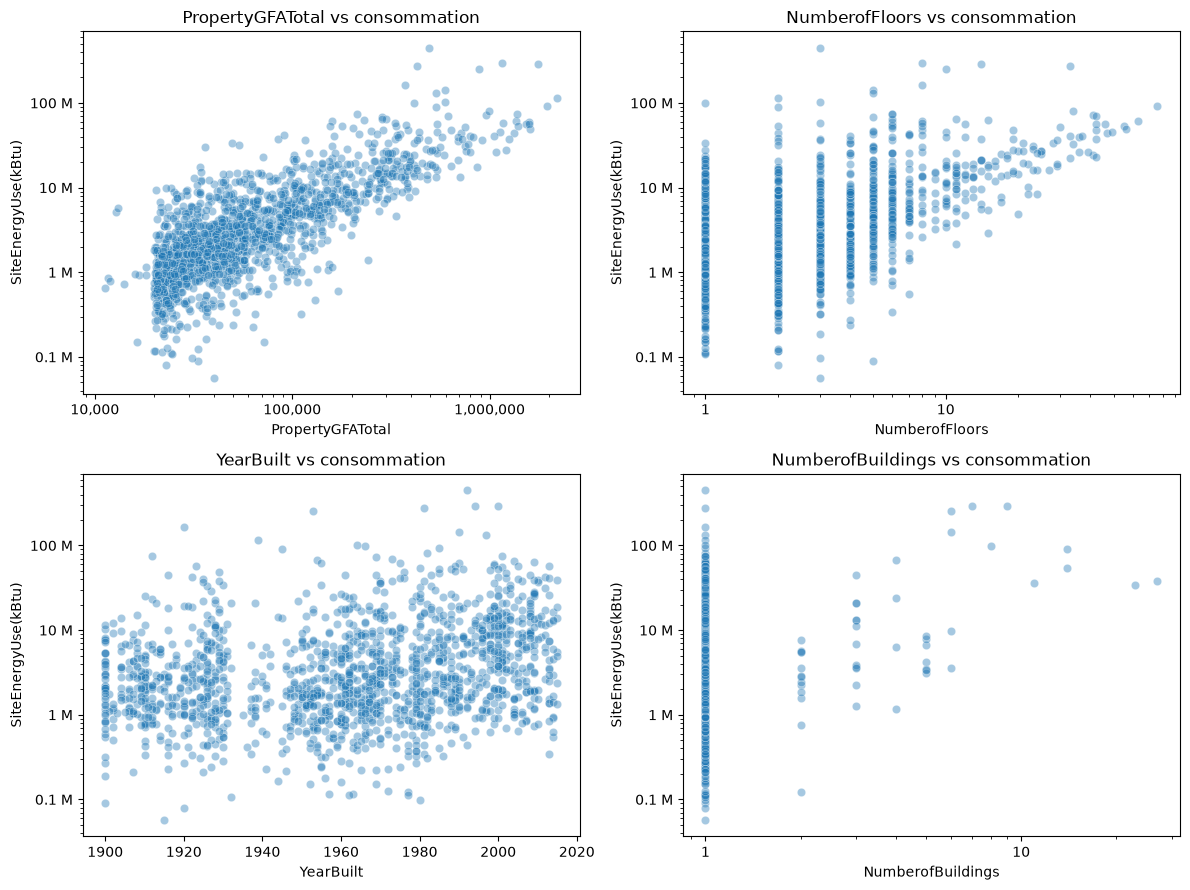

,pearson,spearman
PropertyGFATotal,0.590,0.740
NumberofFloors,0.350,0.470
YearBuilt,0.140,0.280
NumberofBuildings,0.250,0.120


In [91]:
"""Lien entre chaque variable structurelle et la consommation + comparaison Pearson / Spearman"""
from matplotlib.ticker import FuncFormatter  # pour des libellés lisibles au lieu de 10^6

variables = ["PropertyGFATotal", "NumberofFloors", "YearBuilt", "NumberofBuildings"]

# Grille de 2x2 graphiques
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, var in zip(axes.flatten(), variables):
    sns.scatterplot(data=building_consumption, x=var, y=target, ax=ax, alpha=0.4)
    ax.set_yscale("log")  # échelle log : les axes gardent les vraies unités, mais les géants n'écrasent plus tout
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v/1e6:g} M"))  # 1000000 -> "1 M"
    if var != "YearBuilt":  # une année ne se met pas en log
        ax.set_xscale("log")
        ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))  # 100000 -> "100,000"
    ax.set_title(f"{var} vs consommation")

plt.tight_layout()
plt.show()

# Les deux corrélations côte à côte (définitions dans le markdown au-dessus)
correlations = pd.DataFrame({
    "pearson": building_consumption[variables].corrwith(building_consumption[target], method="pearson"),
    "spearman": building_consumption[variables].corrwith(building_consumption[target], method="spearman"),
}).round(2)
correlations

**Lecture des nuages de points et des corrélations**

- **La surface est le lien le plus fort** (Spearman 0,74) : plus un bâtiment est grand, plus il consomme. En échelle log, le nuage forme une bande régulière.
- **Spearman > Pearson pour la surface, les étages et l'année** : la relation existe et va dans un sens régulier, mais elle n'est pas en ligne droite, et les très gros bâtiments perturbent Pearson.
- **`YearBuilt` a un lien faible** (0,14 / 0,28) : l'âge seul explique peu la consommation, et son effet n'est pas linéaire

**Choix :** Spearman reflète mieux les liens sur nos données asymétriques. Je l'utilise pour la suite de l'exploration.

**Corrélations de toutes les colonnes numériques avec la cible (alerte data leakage)**

In [24]:
"""Corrélations (Spearman) de chaque colonne numérique avec la cible : alerte data leakage"""
# On inclut volontairement TOUTES les colonnes numériques, y compris les consommations détaillées
colonnes_numeriques = building_consumption.select_dtypes(include="number")

# Une corrélation très proche de 1 = la colonne "contient" quasiment la réponse -> suspicion de fuite
correlations_target = colonnes_numeriques.corr(method="spearman")[target].sort_values(ascending=False)
print(correlations_target.round(2))

SiteEnergyUse(kBtu)                1.00
SiteEnergyUseWN(kBtu)              0.98
Electricity(kWh)                   0.93
Electricity(kBtu)                  0.93
TotalGHGEmissions                  0.86
PropertyGFATotal                   0.74
SourceEUI(kBtu/sf)                 0.73
PropertyGFABuilding(s)             0.72
SiteEUI(kBtu/sf)                   0.72
SourceEUIWN(kBtu/sf)               0.72
LargestPropertyUseTypeGFA          0.70
SiteEUIWN(kBtu/sf)                 0.69
NumberofFloors                     0.47
GHGEmissionsIntensity              0.44
NaturalGas(therms)                 0.43
NaturalGas(kBtu)                   0.43
PropertyGFAParking                 0.37
SecondLargestPropertyUseTypeGFA    0.34
YearBuilt                          0.28
CouncilDistrictCode                0.23
SteamUse(kBtu)                     0.23
ThirdLargestPropertyUseTypeGFA     0.21
NumberofBuildings                  0.12
Latitude                           0.06
Longitude                         -0.06


**Lecture des corrélations avec la cible**

- **Des colonnes quasi identiques à la cible** : `SiteEnergyUseWN` (0,98), `Electricity` (0,93), `TotalGHGEmissions` (0,86). Ce ne sont pas des caractéristiques du bâtiment mais des **morceaux ou des transformations de la consommation** (version corrigée de la météo, part électrique, émissions calculées à partir de l'énergie). Les utiliser reviendrait à donner la réponse au modèle : **data leakage**
- **Les intensités (`SiteEUI`, `SourceEUI`, ≈ 0,72)** sont aussi de la fuite : elles valent consommation ÷ surface.
- **La corrélation ne suffit pas à repérer la fuite** :
  - la meilleure variable structurelle, `PropertyGFATotal` (0,74), est au même niveau que des colonnes de fuite. Un seuil de corrélation ne permet donc pas de les séparer.
  - à l'inverse, `ENERGYSTARScore` n'est que faiblement corrélé (−0,14), mais il est calculé à partir de la consommation réelle : c'est aussi de la fuite.
- **`ZipCode` (−0,17) et `CouncilDistrictCode` (0,23)** : ces valeurs n'ont pas de sens, car ce sont des **codes de zones** et non des quantités (le code 98104 n'est pas « plus grand » que 98101). Ils seront traités comme des catégories.
- **`Latitude` / `Longitude` (≈ 0)** : pas de lien régulier du type « plus au nord = plus de consommation ». La localisation peut toutefois jouer par zones, ce que le modèle pourra capter.

**Heatmap des liens entre variables structurelles**

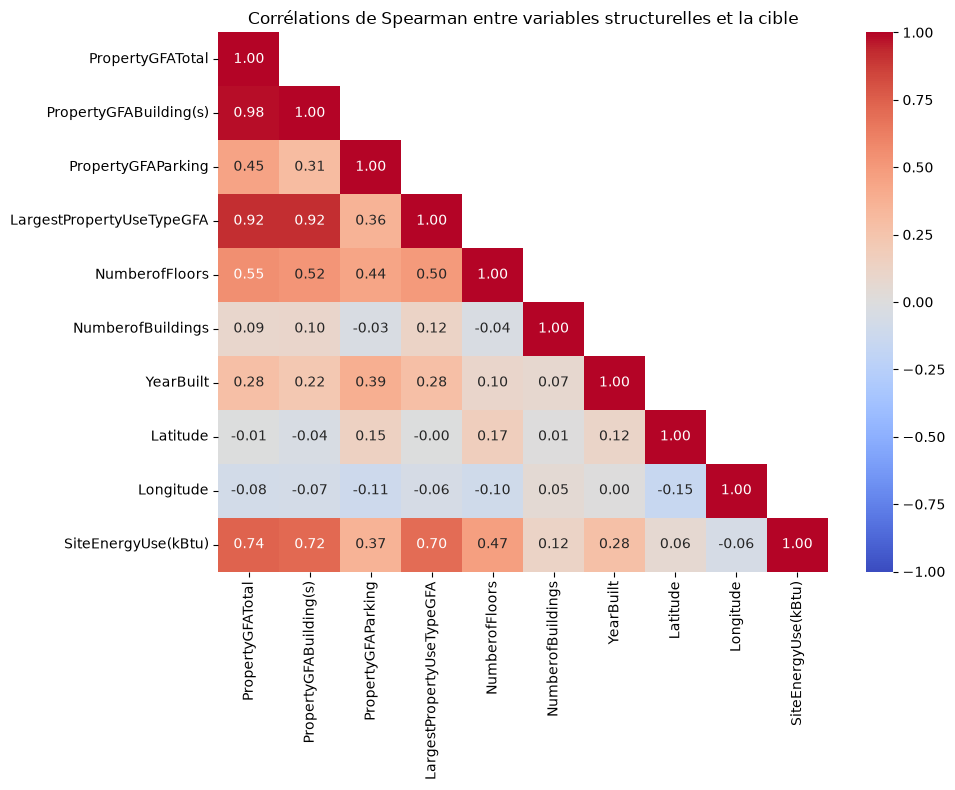

In [25]:
"""Heatmap annotée des variables structurelles (Spearman)"""
# On se limite aux variables structurelles (connues sans mesurer la consommation) + la cible
# -> une matrice lisible, où on peut afficher les valeurs dans les cases
variables_structurelles = [
    "PropertyGFATotal", "PropertyGFABuilding(s)", "PropertyGFAParking",
    "LargestPropertyUseTypeGFA", "NumberofFloors", "NumberofBuildings",
    "YearBuilt", "Latitude", "Longitude", target,
]

# Spearman : choisi plus haut, plus fiable sur nos distributions asymétriques
corr_spearman = building_consumption[variables_structurelles].corr(method="spearman")

# Masque du triangle supérieur : la matrice est symétrique (A-B = B-A), on n'affiche chaque paire qu'une fois
masque = np.triu(np.ones_like(corr_spearman, dtype=bool), k=1)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_spearman,
    mask=masque,
    annot=True, fmt=".2f",   # affiche la valeur dans chaque case, 2 décimales
    cmap="coolwarm", center=0, vmin=-1, vmax=1,  # échelle fixe de -1 à 1 : les couleurs sont comparables
)
plt.title("Corrélations de Spearman entre variables structurelles et la cible")
plt.tight_layout()
plt.show()

**Lecture de la heatmap**

- **Les surfaces sont redondantes entre elles** : `PropertyGFATotal` / `PropertyGFABuilding(s)` = 0,98 et `LargestPropertyUseTypeGFA` ≈ 0,92. Elles portent presque la même information, ce qui sera à traiter avant la modélisation (cf. 3.2).
- **Le nombre d'étages n'est que moyennement lié à la surface (0,55)** : un grand bâtiment peut être bas et étendu (entrepôt) ou haut et compact (tour de bureaux). C'est donc une information complémentaire.
- **Les bâtiments récents sont un peu plus grands** (`YearBuilt` / surface = 0,28) **et ont plus souvent un parking** (0,39). Une partie du lien entre l'année et la consommation (0,28) passe donc probablement par la taille, pas par l'âge lui-même.
- **`NumberofBuildings`, `Latitude` et `Longitude` sont quasi indépendantes** de toutes les autres variables.

**Comparaison de la cible selon le type de bâtiment (`BuildingType`)**

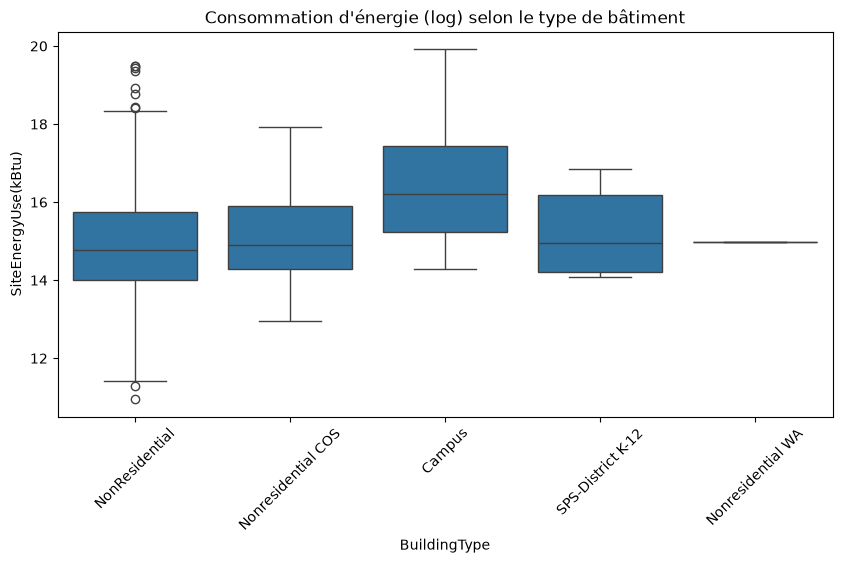

In [26]:
# Comparaison de la target selon le type de bâtiment (variable catégorielle)
# On utilise un boxplot plutôt qu'une corrélation, car BuildingType n'est pas numérique
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=building_consumption,
    x="BuildingType",
    y=np.log(building_consumption[target]),  # on garde le log, plus lisible
)
plt.xticks(rotation=45)
plt.title("Consommation d'énergie (log) selon le type de bâtiment")
plt.show()

Pas très informatif, les `BuildingType` ne sont pas assez variés.
**Je fais la même chose avec `PrimaryPropertyType`**

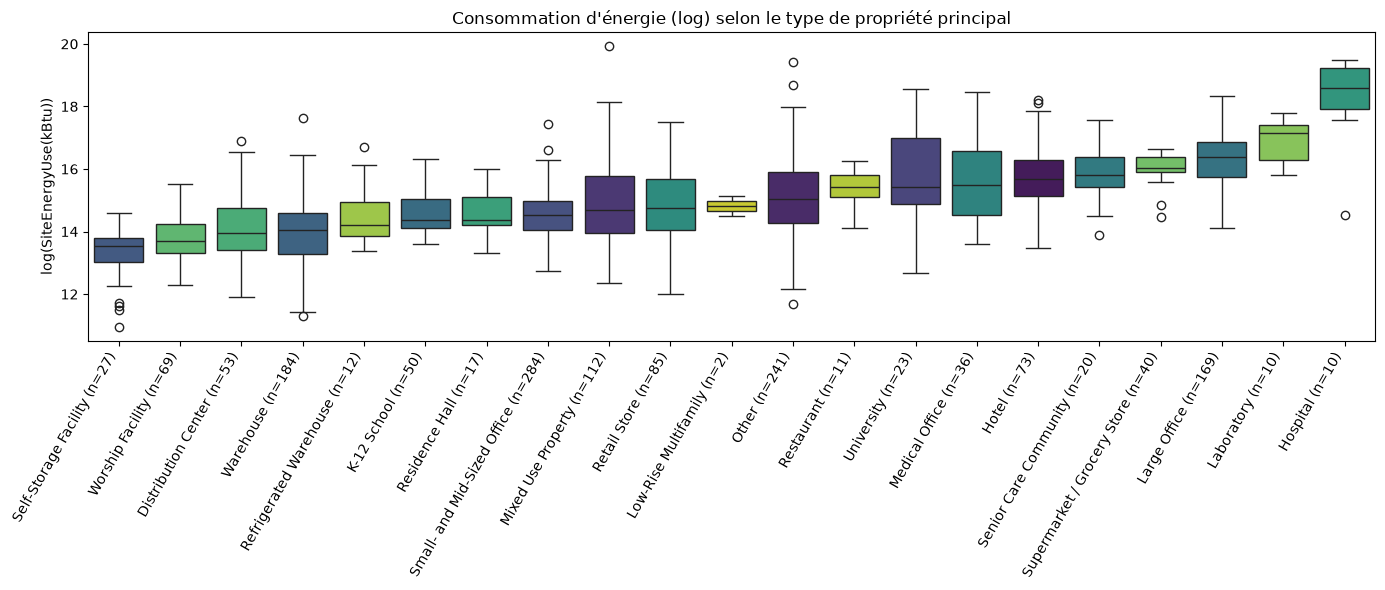

In [27]:
# PrimaryPropertyType est bien plus granulaire que BuildingType, donc plus informatif
# On trie les catégories par médiane de consommation pour rendre le graphique lisible
ordre_categories = (
    building_consumption.groupby("PrimaryPropertyType")[target]
    .median()
    .sort_values(ascending=True)
    .index
)

# Nombre de bâtiments par catégorie, remis dans le MÊME ordre que les boîtes du graphique
# (reindex = "réordonne selon cette liste")
effectifs = building_consumption["PrimaryPropertyType"].value_counts().reindex(ordre_categories)

plt.figure(figsize=(14, 6))
ax = sns.boxplot(          # on stocke le graphique dans "ax" pour pouvoir le modifier ensuite
    data=building_consumption,
    x="PrimaryPropertyType",
    y=np.log(building_consumption[target]),
    hue="PrimaryPropertyType",
    palette="viridis",
    order=ordre_categories,  # applique le tri qu'on vient de calculer
    legend=False,            # la couleur sert juste à distinguer les boîtes, pas besoin de légende
)

# On remplace les libellés de l'axe X par "Nom de la catégorie (n=effectif)"
# Rappel : une boîte construite sur 2-3 bâtiments est peu fiable, le "n" permet de le voir d'un coup d'oeil
nouveaux_labels = [f"{categorie} (n={n})" for categorie, n in effectifs.items()]
ax.set_xticks(range(len(ordre_categories)))   # une graduation par boîte
ax.set_xticklabels(nouveaux_labels, rotation=60, ha="right")

ax.set_xlabel("")  # le nom de l'axe est inutile, les libellés parlent d'eux-mêmes
ax.set_ylabel(f"log({target})")
plt.title("Consommation d'énergie (log) selon le type de propriété principal")
plt.tight_layout()
plt.show()

On constate que le `PrimaryPropertyType` est plus parlant et que les grands bureaux, les laboratoires et les hôpitaux sont dans le haut des consommations

**Bâtiments mono-usage vs multi-usages**

Multi-usages    0.55
Mono-usage      0.45
Name: proportion, dtype: float64
              PropertyGFATotal  SiteEnergyUse(kBtu)
Mono-usage             41255.0           1958519.25
Multi-usages           56942.0           3603160.50
Mono-usage      49.75
Multi-usages    56.75
Name: SiteEUI(kBtu/sf), dtype: float64


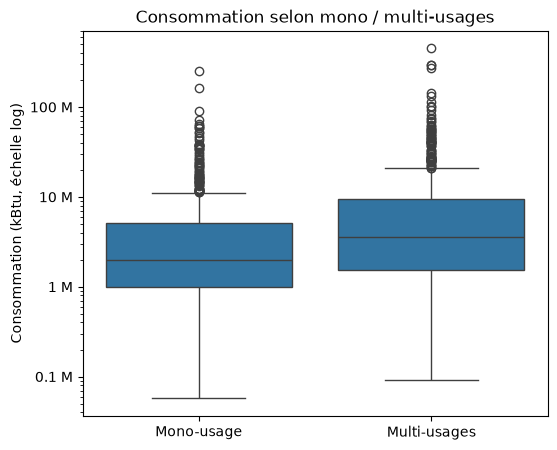

In [28]:
"""Comparaison des bâtiments mono-usage et multi-usages"""
from matplotlib.ticker import FuncFormatter  # sert à rendre l'axe Y lisible ("1 M" au lieu de 10^6)

# Série temporaire (pas ajoutée au dataframe) : un bâtiment est "multi" s'il a un 2e usage déclaré
type_usage = np.where(building_consumption["SecondLargestPropertyUseType"] == "None", "Mono-usage", "Multi-usages")

# Combien de bâtiments dans chaque groupe ?
print(pd.Series(type_usage).value_counts(normalize=True).round(2))  # en proportion

# Médianes par groupe : surface et consommation
# (médiane et pas moyenne, car les distributions sont asymétriques -> cf. 1.8)
print(building_consumption.groupby(type_usage)[["PropertyGFATotal", target]].median())

# Consommation PAR SURFACE (kBtu/sqft) : neutralise l'effet taille
# -> si les multi-usages consomment aussi plus par sqft, l'écart ne vient pas que de leur taille
print(building_consumption.groupby(type_usage)["SiteEUI(kBtu/sf)"].median())

# Boxplot de la consommation (log) par groupe
plt.figure(figsize=(6, 5))
sns.boxplot(x=type_usage, y=building_consumption[target])
plt.yscale("log")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda valeur, _: f"{valeur/1e6:g} M"))
plt.title("Consommation selon mono / multi-usages")
plt.ylabel("Consommation (kBtu, échelle log)")
plt.show()

**Mono-usage vs multi-usages**

- **55 % des bâtiments sont multi-usages.**
- En médiane, ils sont **38 % plus grands** (56 942 vs 41 255 sqft) et consomment **84 % de plus** (3,6 M vs 2,0 M kBtu).
- Pour séparer l'effet de la taille, je compare la **consommation par sqft** (`SiteEUI`) : les multi-usages consomment **14 % de plus par sqft** (56,8 vs 49,8 kBtu/sqft).

**Conclusion :** l'écart de consommation vient **surtout de la taille** des bâtiments multi-usages, mais le mélange d'usages ajoute un effet propre, plus modeste.
Cela justifie de donner au modèle l'information sur les usages secondaires.

*Note : `SiteEUI` est utilisée ici uniquement pour l'exploration. Elle est calculée à partir de la consommation réelle, donc elle sera retirée avant la modélisation pour éviter le data leakage

**Vue croisée des principales variables (pairplot)**

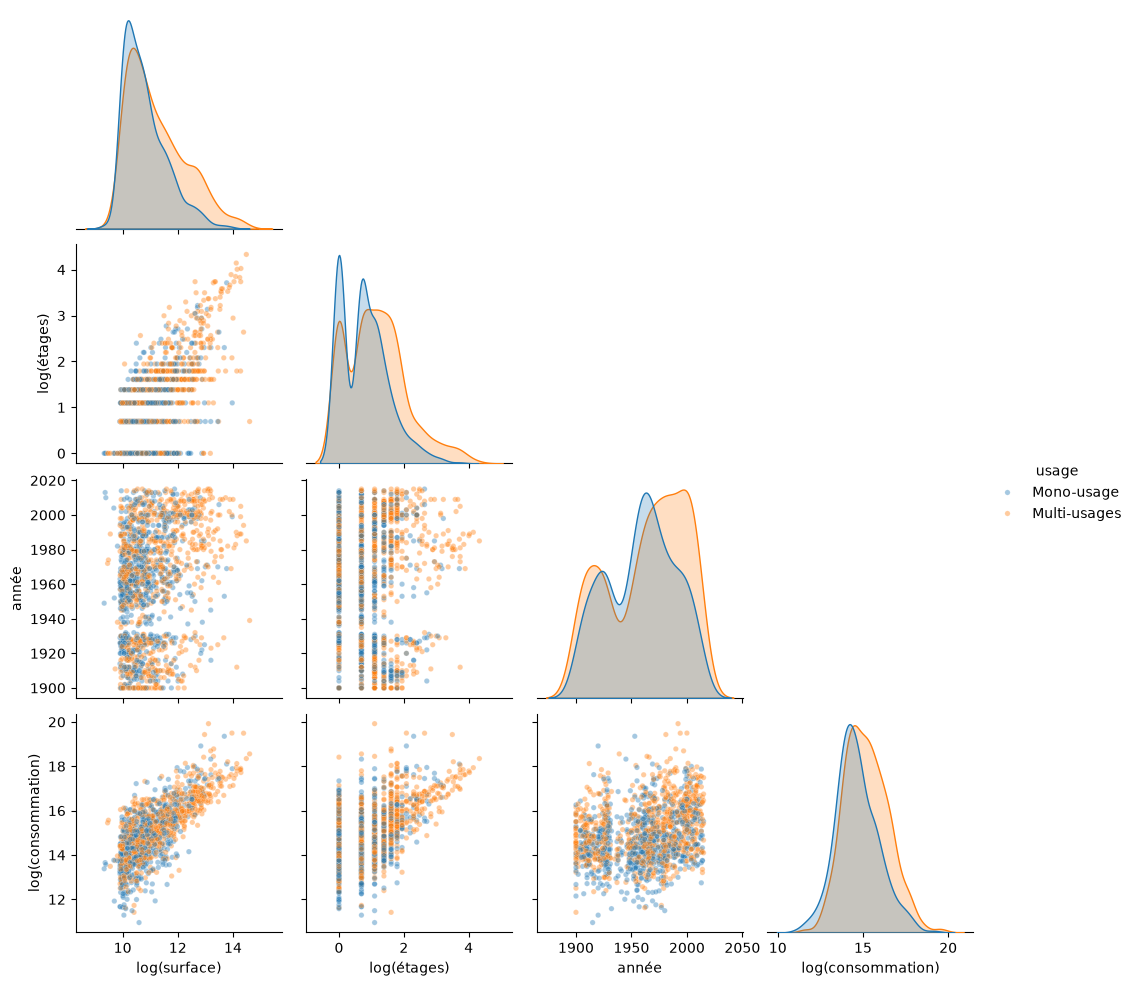

In [29]:
"""Pairplot : vue croisée des principales variables (mono vs multi-usages)"""
# Tableau temporaire, avec le log des variables asymétriques (cf. 1.8) pour que les nuages soient lisibles
# Parking exclu : 80 % de zéros, et log(0) est impossible
donnees_pairplot = pd.DataFrame({
    "log(surface)": np.log(building_consumption["PropertyGFATotal"]),
    "log(étages)": np.log(building_consumption["NumberofFloors"]),
    "année": building_consumption["YearBuilt"],
    "log(consommation)": np.log(building_consumption[target]),
    "usage": type_usage,   # défini dans la cellule mono/multi juste au-dessus
})

# corner=True : n'affiche que le triangle inférieur (le reste serait en double)
# hue="usage" : une couleur par groupe mono / multi
sns.pairplot(donnees_pairplot, hue="usage", corner=True, plot_kws={"alpha": 0.4, "s": 15})
plt.show()

**Lecture du pairplot**

- **log(surface) vs log(consommation)** : une bande nette et quasi rectiligne. En échelle log, le lien taille/consommation est presque linéaire, ce qui conforte le passage de la cible en log pour la modélisation.
- **Plus aucun point isolé en nombre d'étages** : le bâtiment de 99 étages n'apparaît plus. Le plus haut est désormais à 76 étages, cohérent avec sa surface.
- **Distribution des années en deux vagues** (1900-1930 et 1950-2010), avec un creux autour de 1930-1945 qui correspond à la crise et à la guerre. Les multi-usages sont surreprésentés parmi les constructions récentes.
- **Sur la diagonale, les multi-usages (orange) sont décalés vers la droite** en surface, en étages et en consommation, ce qui confirme l'analyse mono/multi.

## 1.10 Récap du nombre de lignes par étapes

| Étape | Bâtiments | Retirés | Corrigés |
|---|---|---|---|
| Relevés initiaux | 3 376 | – | – |
| Non résidentiels | 1 668 | 1 708 | – |
| Usage principal renseigné | 1 662 | 6 | – |
| Données conformes | 1 544 | 118 | – |
| Au moins 1 étage | 1 528 | 16 | – |
| Imputation : église à 99 étages (→ 2 étages) | 1 528 | – | 1 |
| Imputation : 0 bâtiment (→ 1 bâtiment) | 1 528 | – | 51 |
| Sans outliers (partie 3) | 1 516 | 12 | – |

# Modélisation

### Import des modules

In [30]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


# 2. Feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes.

En règle générale : On utilise la méthode .apply() de Pandas pour créer une nouvelle colonne à partir d'une colonne existante. N'hésitez pas à regarder les exemples dans les chapitres de cours donnés en ressource -> J'ai préféré faire en vectorisé, je trouve ça plus lisible

In [31]:
# CODE FEATURE ENGINEERING

## 2.1 Temporalité : analyse par année, puis par décennie, et création de decennie_construction

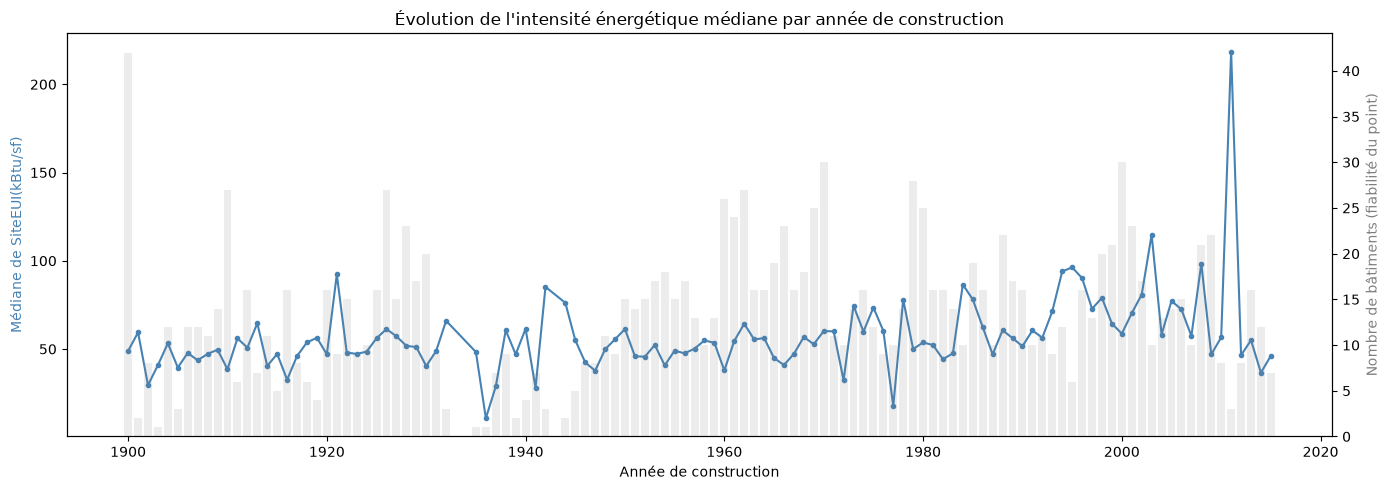

In [32]:
# Afin de pouvoir avancer dans le feature engineering
# Je vérifie si l'on peut observer une Année avec une cassure en terme d'efficience
# On utilise SiteEUI plutôt que la target brute, car je cherche ici un effet, indépendant de la taille du batiment
metrique_efficience = "SiteEUI(kBtu/sf)"

conso_par_annee = building_consumption.groupby("YearBuilt")[metrique_efficience].median()
nb_batiments_par_annee = building_consumption.groupby("YearBuilt")[metrique_efficience].count()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(conso_par_annee.index, conso_par_annee.values, color="steelblue", marker="o", markersize=3)
ax1.set_xlabel("Année de construction")
ax1.set_ylabel(f"Médiane de {metrique_efficience}", color="steelblue")
ax1.set_title("Évolution de l'intensité énergétique médiane par année de construction")

ax2 = ax1.twinx()
ax2.bar(nb_batiments_par_annee.index, nb_batiments_par_annee.values, alpha=0.15, color="gray")
ax2.set_ylabel("Nombre de bâtiments (fiabilité du point)", color="gray")

plt.tight_layout()
plt.show()

Pas vraiment d'année atypique, à part 2010 mais seulement 3 batiments contruits donc médiane biaisé  
Je teste en dessous en faisant un bucketing par décénnie de construction

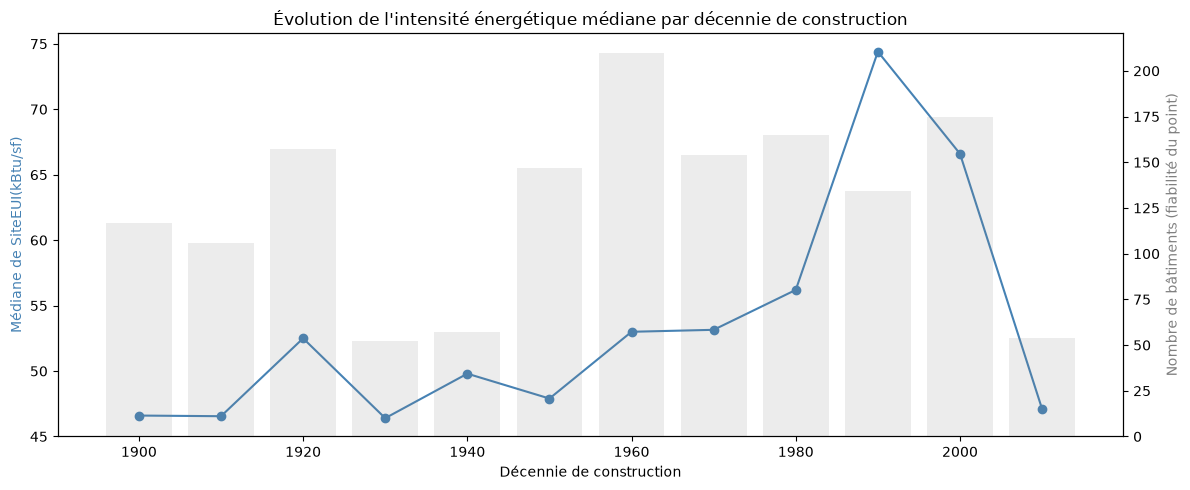

In [33]:
# Même analyse, mais regroupée par décennie plutôt que par année exacte
building_consumption["decennie_construction"] = (building_consumption["YearBuilt"] // 10) * 10

conso_par_decennie = building_consumption.groupby("decennie_construction")[metrique_efficience].median()
nb_batiments_par_decennie = building_consumption.groupby("decennie_construction")[metrique_efficience].count()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(conso_par_decennie.index, conso_par_decennie.values, color="steelblue", marker="o")
ax1.set_xlabel("Décennie de construction")
ax1.set_ylabel(f"Médiane de {metrique_efficience}", color="steelblue")
ax1.set_title("Évolution de l'intensité énergétique médiane par décennie de construction")

ax2 = ax1.twinx()
ax2.bar(nb_batiments_par_decennie.index, nb_batiments_par_decennie.values, width=8, alpha=0.15, color="gray")
ax2.set_ylabel("Nombre de bâtiments (fiabilité du point)", color="gray")

plt.tight_layout()
plt.show()

On constate plusieurs tendances en fonction des décennies, augmentation ou diminution de l'efficience par sqft

In [34]:
"""Feature Engineering - Temporalité"""

# On transforme l'année de construction en décennie (catégorielle)
building_consumption["decennie_construction"] = (building_consumption["YearBuilt"] // 10) * 10

# On vérifie que chaque décennie a un volume de bâtiments suffisant pour être exploitable
print(building_consumption["decennie_construction"].value_counts().sort_index())

decennie_construction
1900    117
1910    106
1920    157
1930     52
1940     57
1950    147
1960    210
1970    154
1980    165
1990    134
2000    175
2010     54
Name: count, dtype: int64


## 2.2 Sources d'énergie : vérifications, puis indicateurs 0/1

In [35]:
# Vérification préalable avant de créer les indicateurs de source d'énergie :
colonnes_energie = ["Electricity(kWh)", "NaturalGas(therms)", "SteamUse(kBtu)"]

for col in colonnes_energie:
    print(f"--- {col} ---")
    print(f"Nb de NaN : {building_consumption[col].isnull().sum()}")
    print(f"Nb de valeurs == 0 : {(building_consumption[col] == 0).sum()}")
    print(building_consumption[col].describe())
    print()

--- Electricity(kWh) ---
Nb de NaN : 0
Nb de valeurs == 0 : 2
count    1.528000e+03
mean     1.657026e+06
std      4.025887e+06
min     -3.382680e+04
25%      2.129975e+05
50%      4.966785e+05
75%      1.504899e+06
max      8.046087e+07
Name: Electricity(kWh), dtype: float64

--- NaturalGas(therms) ---
Nb de NaN : 0
Nb de valeurs == 0 : 438
count    1.528000e+03
mean     2.017102e+04
std      9.748393e+04
min      0.000000e+00
25%      0.000000e+00
50%      4.803805e+03
75%      1.524242e+04
max      2.979090e+06
Name: NaturalGas(therms), dtype: float64

--- SteamUse(kBtu) ---
Nb de NaN : 0
Nb de valeurs == 0 : 1418
count    1.528000e+03
mean     4.889622e+05
std      5.320966e+06
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.349435e+08
Name: SteamUse(kBtu), dtype: float64



Pas de NaN  
Attention sur le min négatif sur `Electricity(kWh)`, peut indiquer un bâtiment avec des panneaux solaires

In [36]:
"""Feature Engineering - Type d'energie utilisée par le batiment"""

# Indicateurs binaires de présence de chaque source d'énergie
# On utilise "!= 0" plutôt que "> 0" pour bien capturer les cas de bâtiments
# producteurs (ex: Bullitt Center, qui a un solde électrique négatif)
building_consumption["Electricity_Use"] = (building_consumption["Electricity(kWh)"] != 0).astype(int)
building_consumption["Gas_Use"] = (building_consumption["NaturalGas(therms)"] != 0).astype(int)
building_consumption["Steam_Use"] = (building_consumption["SteamUse(kBtu)"] != 0).astype(int)

# Combien de bâtiments utilisent chaque source
print(building_consumption[["Electricity_Use", "Gas_Use", "Steam_Use"]].sum())

Electricity_Use    1526
Gas_Use            1090
Steam_Use           110
dtype: int64


On note que presque la totalité des batiments ont `Electricity_Use` = 1

## 2.3 Usages multiples : indicateurs 0/1 et proportions par usage

In [37]:
"""Feature Engineering - Usages multiples"""

# Indicateurs binaires : le bâtiment a-t-il un usage secondaire / tertiaire ?
building_consumption["Has_Second_Use"] = (building_consumption["SecondLargestPropertyUseType"] != "None").astype(int)
building_consumption["Has_Third_Use"] = (building_consumption["ThirdLargestPropertyUseType"] != "None").astype(int)

# Proportions : quelle part de la surface totale est occupée par ces usages secondaire/tertiaire ?
# (entre 0 et 1 : 0 = aucune surface dédiée à cet usage, 1 = 100% du bâtiment)
building_consumption["Prop_Second_Use"] = building_consumption["SecondLargestPropertyUseTypeGFA"] / building_consumption["PropertyGFATotal"]
building_consumption["Prop_Third_Use"] = building_consumption["ThirdLargestPropertyUseTypeGFA"] / building_consumption["PropertyGFATotal"]

# Contrôle rapide : cohérence des nouvelles colonnes
print(building_consumption[["Has_Second_Use", "Has_Third_Use", "Prop_Second_Use", "Prop_Third_Use"]].describe())

       Has_Second_Use  Has_Third_Use  Prop_Second_Use  Prop_Third_Use
count     1528.000000    1528.000000      1528.000000     1528.000000
mean         0.545812       0.225785         0.129743        0.023275
std          0.498060       0.418235         0.170282        0.064017
min          0.000000       0.000000         0.000000        0.000000
25%          0.000000       0.000000         0.000000        0.000000
50%          1.000000       0.000000         0.000000        0.000000
75%          1.000000       0.000000         0.250000        0.000000
max          1.000000       1.000000         1.293221        0.929094


## 2.4 Récapitulatif des features créées

8 nouvelles features, réparties en 3 familles d'informations :

| Famille | Feature | Type | Contenu |
|---|---|---|---|
| Temporalité | `decennie_construction` | Catégorielle | Décennie de construction (ex : 1990) |
| Sources d'énergie | `Electricity_Use` | Binaire (0/1) | Le bâtiment utilise de l'électricité (presque tous à 1) |
| | `Gas_Use` | Binaire (0/1) | Le bâtiment utilise du gaz |
| | `Steam_Use` | Binaire (0/1) | Le bâtiment utilise de la vapeur |
| Usages multiples | `Has_Second_Use` / `Has_Third_Use` | Binaire (0/1) | Le bâtiment a un 2e / 3e usage |
| | `Prop_Second_Use` / `Prop_Third_Use` | Numérique (0 à 1) | Part de la surface dédiée au 2e / 3e usage |

**Pourquoi ces choix :**
- **Décennie plutôt qu'année** : l'effet de l'âge sur l'intensité énergétique n'est pas linéaire (les bâtiments des années 1990-2000 sont les moins efficients). Regrouper par décennie donne des groupes assez grands pour être fiables.
- **Présence plutôt que quantité d'énergie** : les quantités consommées (kWh, therms) sont des morceaux de la cible, donc du *data leakage*. Savoir si un bâtiment est équipé au gaz est en revanche une information structurelle, connue sans mesurer la consommation.
- **Usages multiples** : un bâtiment mixte (bureaux + parking, par exemple) ne consomme pas comme un bâtiment mono-usage. Les proportions indiquent en plus quel poids a chaque usage.

> Pas de fuite de données : toutes ces features peuvent être calculées pour un bâtiment dont on ne connaît pas encore la consommation.

# 3. Préparation des features pour la modélisation

A réaliser :
* Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.
* Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.
* Débarrassez-vous des features redondantes en utilisant une matrice de corrélation de Pearson. Pour cela, utiisez la méthode corr() de Pandas, couplé d'un graphique Heatmap de la librairie Seaborn
* Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).
*  Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).
* Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne. Les deux méthodes d'encodage à connaitre sont le OneHotEncoder et le LabelEncoder

In [38]:
# CODE PREPARATION DES FEATURES

## 3.1 Suppression des colonnes (leakage, constantes, identifiants, redondantes)

In [39]:
"""Suppression de Features"""

# --- Groupe 1 : Data leakage ---
colonnes_leakage = [
    "SiteEnergyUseWN(kBtu)",
    "Electricity(kWh)", "Electricity(kBtu)",
    "NaturalGas(therms)", "NaturalGas(kBtu)",
    "SteamUse(kBtu)",
    "TotalGHGEmissions", "GHGEmissionsIntensity",
    "SiteEUI(kBtu/sf)", "SiteEUIWN(kBtu/sf)",
    "SourceEUI(kBtu/sf)", "SourceEUIWN(kBtu/sf)",
    "ENERGYSTARScore",
]

# --- Groupe 2 : Colonnes devenues constantes après nos filtres ---
colonnes_constantes = ["ComplianceStatus", "DefaultData"]

# --- Groupe 3 : Identifiant peu exploitable ---
colonnes_identifiants = ["PropertyName"]

# --- Groupe 4 : Colonnes brutes redondantes avec des features déjà créées ---
# YearBuilt remplacée par decennie_construction car les variations n'étaient pas assez visibles sinon
# Second/ThirdLargestPropertyUseTypeGFA -> remplacées par Prop_Second_Use / Prop_Third_Use
colonnes_redondantes = [
    "YearBuilt",
    "SecondLargestPropertyUseTypeGFA",
    "ThirdLargestPropertyUseTypeGFA",
]

# --- Groupe 5 : Cardinalité trop élevée pour être exploitable (quasi 1 valeur par bâtiment) ---
# Son information a déjà été extraite via Has_Second_Use / Has_Third_Use
colonnes_trop_eparses = ["ListOfAllPropertyUseTypes"]

building_consumption = building_consumption.drop(
    columns=colonnes_leakage + colonnes_constantes + colonnes_identifiants + colonnes_redondantes + colonnes_trop_eparses
)

# Contrôle : combien de colonnes te reste-t-il, et sont-elles cohérentes ?
print(f"Nombre de colonnes restantes : {building_consumption.shape[1]}")
building_consumption.info()

Nombre de colonnes restantes : 25
<class 'pandas.DataFrame'>
Index: 1528 entries, 0 to 3375
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   BuildingType                  1528 non-null   str    
 1   PrimaryPropertyType           1528 non-null   str    
 2   ZipCode                       1515 non-null   float64
 3   CouncilDistrictCode           1528 non-null   int64  
 4   Neighborhood                  1528 non-null   str    
 5   Latitude                      1528 non-null   float64
 6   Longitude                     1528 non-null   float64
 7   NumberofBuildings             1528 non-null   float64
 8   NumberofFloors                1528 non-null   int64  
 9   PropertyGFATotal              1528 non-null   int64  
 10  PropertyGFAParking            1528 non-null   int64  
 11  PropertyGFABuilding(s)        1528 non-null   int64  
 12  LargestPropertyUseType        1528 non-null 

## 3.2 Corrélations après nettoyage

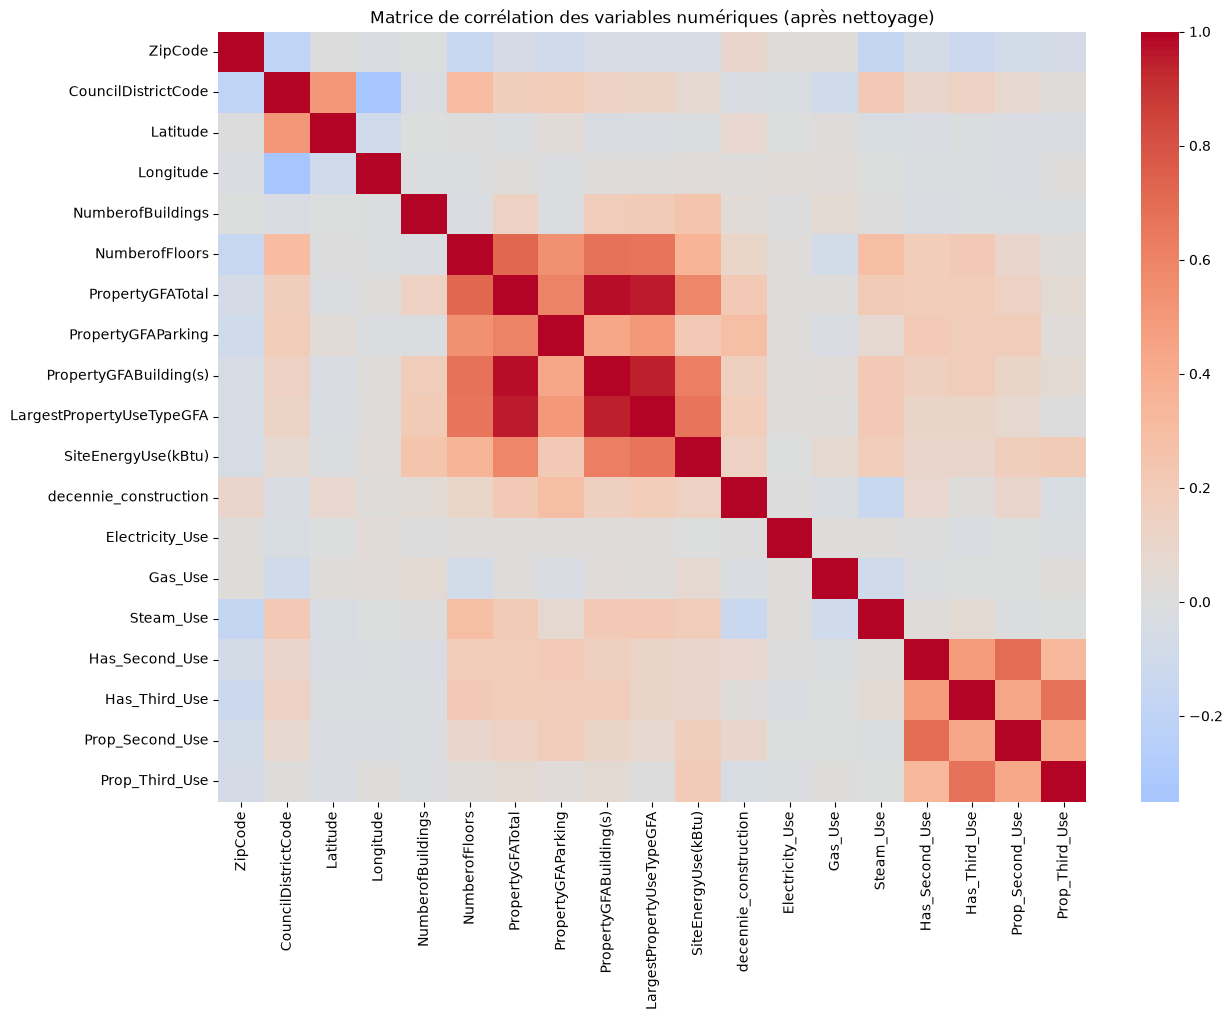

In [40]:
# On relance la matrice de corrélation sur le dataframe nettoyé
# (après suppression du leakage et des redondances "par formule")
colonnes_numeriques = building_consumption.select_dtypes(include="number")
corr_matrix = colonnes_numeriques.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False)
plt.title("Matrice de corrélation des variables numériques (après nettoyage)")
plt.show()

### Analyse matrices de corrélation

**Après nettoyage : ce qu'on observe**

- **La surface est le signal principal** : `PropertyGFATotal`, `PropertyGFABuilding(s)` et `LargestPropertyUseTypeGFA` sont les features les plus corrélées à la cible (≈ 0,6 à 0,7). C'est cohérent : plus un bâtiment est grand, plus il consomme.
- **Mais ces 3 colonnes de surface sont redondantes entre elles** (≈ 0,95) : elles portent quasiment la même information. `NumberofFloors` y est aussi liée (≈ 0,7), puisque plus d'étages implique plus de surface.
- **Les features d'usages multiples que j'ai créées, sont liées entre elles** (`Has_Second_Use` / `Prop_Second_Use` ≈ 0,7), ce qui est logique puisque la proportion vaut 0 quand il n'y a pas de 2e usage.
- **La localisation ne ressort pas** (≈ 0 avec la cible). C'est attendu : `ZipCode` et `CouncilDistrictCode` sont des codes de zones, pas des quantités, et Pearson n'a pas de sens sur eux. Ils seront convertis en texte en 3.5, puis encodés en One-Hot en 3.8.
- **`Electricity_Use` n'est corrélée à rien** : quasiment tous les bâtiments utilisent de l'électricité, la colonne est presque constante et apporte très peu d'information.

## 3.3 Outliers de la cible : IQR en échelle brute ou en log

In [41]:
"""Calcul de l'IQR pour identifier de potentiels Outliers au sens statistique"""
# Méthode IQR (interquartile range) : une valeur est considérée outlier statistique
# si elle est en dehors de [Q1 - 1.5*IQR ; Q3 + 1.5*IQR]
Q1 = building_consumption[target].quantile(0.25)
Q3 = building_consumption[target].quantile(0.75)
IQR = Q3 - Q1
borne_basse = Q1 - 1.5 * IQR
borne_haute = Q3 + 1.5 * IQR

nb_outliers = ((building_consumption[target] < borne_basse) | (building_consumption[target] > borne_haute)).sum()
print(f"Nombre d'outliers statistiques (méthode IQR) : {nb_outliers} sur {len(building_consumption)} bâtiments")

Nombre d'outliers statistiques (méthode IQR) : 169 sur 1528 bâtiments


Ce calcul nous ferait retirer 11 % des bâtiments, tout comme au début du notebook, je fais le même calcul en log pour être un peu moins aggressif

In [42]:
# Comme l'IQR précédent faisait retirer presque 10% des lignes, je teste sur l'échelle log pour voir si ça change quelque chose pour comparer
# IQR sur l'échelle brute de la target
Q1 = building_consumption[target].quantile(0.25)
Q3 = building_consumption[target].quantile(0.75)
IQR = Q3 - Q1
borne_basse = Q1 - 1.5 * IQR
borne_haute = Q3 + 1.5 * IQR

nb_outliers_brut = ((building_consumption[target] < borne_basse) | (building_consumption[target] > borne_haute)).sum()
print(f"IQR (échelle brute) : bornes [{borne_basse:.0f} ; {borne_haute:.0f}]")
print(f"Outliers détectés : {nb_outliers_brut} / {len(building_consumption)} ({100*nb_outliers_brut/len(building_consumption):.1f}%)")

# Même calcul, mais sur l'échelle log (rappel : on avait vu que log(target) est bien plus symétrique, skewness ≈ 0.36)
log_target = np.log(building_consumption[target])
Q1_log = log_target.quantile(0.25)
Q3_log = log_target.quantile(0.75)
IQR_log = Q3_log - Q1_log
borne_basse_log = Q1_log - 1.5 * IQR_log
borne_haute_log = Q3_log + 1.5 * IQR_log

nb_outliers_log = ((log_target < borne_basse_log) | (log_target > borne_haute_log)).sum()
print(f"IQR (échelle log) : bornes [{np.exp(borne_basse_log):.0f} ; {np.exp(borne_haute_log):.0f}] (reconverties en kBtu)")
print(f"Outliers détectés : {nb_outliers_log} / {len(building_consumption)} ({100*nb_outliers_log/len(building_consumption):.1f}%)")

IQR (échelle brute) : bornes [-7755116 ; 16242034]
Outliers détectés : 169 / 1528 (11.1%)
IQR (échelle log) : bornes [88512 ; 101783533] (reconverties en kBtu)
Outliers détectés : 12 / 1528 (0.8%)


C'est mieux, uniquement 12 lignes

In [43]:
# On retient la version log (la moins invasive, cohérente avec la vraie forme de la distribution)
# On applique la suppression sur les bornes calculées précédemment (borne_basse_log / borne_haute_log)
nb_avant = building_consumption.shape[0]

building_consumption = building_consumption[
    (log_target >= borne_basse_log) & (log_target <= borne_haute_log)
]

nb_apres = building_consumption.shape[0]
print(f"Nombre de bâtiments après suppression des outliers (IQR sur échelle log) : {nb_apres}")
print(f"Lignes supprimées : {nb_avant - nb_apres}")

Nombre de bâtiments après suppression des outliers (IQR sur échelle log) : 1516
Lignes supprimées : 12


## 3.4 Relation entre surface et consommation

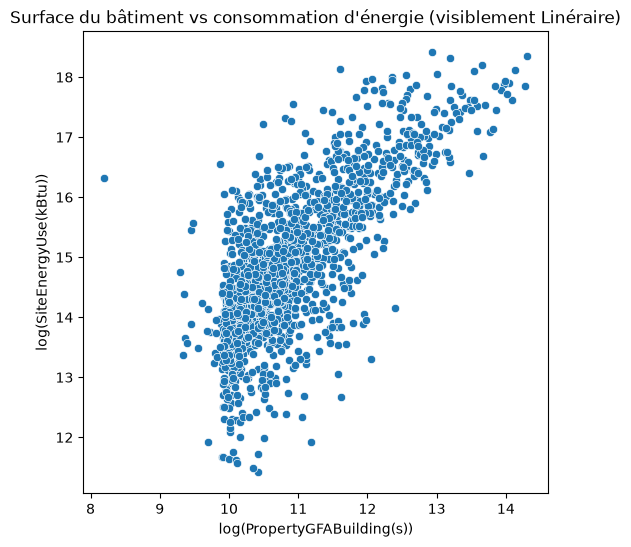

In [44]:
# Relation entre la surface du bâtiment et la consommation d'énergie
# On passe les deux axes en log, cohérent avec ce qu'on a observé sur la distribution de la target
plt.figure(figsize=(6, 6))
sns.scatterplot(
    x=np.log(building_consumption["PropertyGFABuilding(s)"]),
    y=np.log(building_consumption[target]),
)
plt.xlabel("log(PropertyGFABuilding(s))")
plt.ylabel(f"log({target})")
plt.title("Surface du bâtiment vs consommation d'énergie (visiblement Linéraire)")
plt.show()

Corrélation assez linéaire observable

## 3.5 Typage des variables catégorielles

In [45]:
"""Nettoyage de colonnes catégorielles"""

# On force decennie_construction en texte pour qu'elle soit bien traitée comme catégorielle par OneHot
building_consumption["decennie_construction"] = building_consumption["decennie_construction"].astype(str)

# Même logique que pour decennie_construction : ce sont des identifiants de zones, pas des quantités
building_consumption["CouncilDistrictCode"] = building_consumption["CouncilDistrictCode"].astype(str)
building_consumption["ZipCode"] = building_consumption["ZipCode"].astype(str)

## 3.6 Choix de max_categories et test du OneHotEncoder

In [46]:
"""Méthode pour déterminer un nombre de catégories suffisant pour couvrir 90% des bâtiments"""

# Méthode : on choisit le nombre minimal de catégories qui couvre au moins 90% des bâtiments,
# plutôt que de fixer max_categories arbitrairement
# Je pars sur ZipCode car c'est elle qui a le plus de valeurs et risque de faire beaucoup de colonnes
seuil_couverture = 0.90

# value_counts() : nombre de bâtiments par code postal, trié du plus fréquent au moins fréquent
vc = building_consumption["ZipCode"].value_counts()

# Couverture cumulée : part des bâtiments couverts si on garde les 1, 2, 3... premiers codes postaux
# cumsum() additionne au fur et à mesure
# / vc.sum() divise par le total des bâtiments pour obtenir la proportion
couverture_cumulee = vc.cumsum() / vc.sum()

# Nombre de catégories nécessaires pour atteindre le seuil
nb_categories_necessaire = (couverture_cumulee < seuil_couverture).sum() + 1
print(f"Nombre de catégories nécessaire pour couvrir {seuil_couverture*100:.0f}% des bâtiments : {nb_categories_necessaire}")
print(f"Couverture réelle avec ce nombre : {couverture_cumulee.iloc[nb_categories_necessaire-1]*100:.1f}%")

Nombre de catégories nécessaire pour couvrir 90% des bâtiments : 18
Couverture réelle avec ce nombre : 91.3%


In [47]:
'''Bloc de test uniquement'''
# On sépare d'abord les features catégorielles (object et str) à traiter et on stocke dans des variables à part, cela sera recalculé plus loin
colonnes_categorielles = building_consumption.select_dtypes(include=["object", "str"]).columns.tolist()
print("Colonnes catégorielles à encoder :", colonnes_categorielles)

# max_categories=18 : au-delà des 17 valeurs les plus fréquentes, le reste est regroupé dans une catégorie "infrequent" (+1)
encoder = OneHotEncoder(handle_unknown="ignore", max_categories=18, sparse_output=False)

# Test rapide sur une seule colonne pour vérifier le comportement avant de l'intégrer au ColumnTransformer
test_encodage = encoder.fit_transform(building_consumption[["LargestPropertyUseType"]])
print(f"Nombre de colonnes générées pour LargestPropertyUseType : {test_encodage.shape[1]}")

Colonnes catégorielles à encoder : ['BuildingType', 'PrimaryPropertyType', 'ZipCode', 'CouncilDistrictCode', 'Neighborhood', 'LargestPropertyUseType', 'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType', 'decennie_construction']
Nombre de colonnes générées pour LargestPropertyUseType : 18


## 3.7 Séparation X / y

In [48]:
# On sépare les features (X) de la target (y)
X = building_consumption.drop(columns=[target])
y = building_consumption[target]

print(f"Shape de X : {X.shape}")
print(f"Shape de y : {y.shape}")

Shape de X : (1516, 24)
Shape de y : (1516,)


## 3.8 Définition du préprocessing (encodage + scaling)

In [49]:
# On identifie les 2 groupes de colonnes à partir de X (pas building_consumption, pour être sûr de ne pas inclure la target)
colonnes_categorielles = X.select_dtypes(include=["object", "str"]).columns.tolist()
colonnes_numeriques = X.select_dtypes(include="number").columns.tolist()

print("Catégorielles :", colonnes_categorielles)
print("Numériques :", colonnes_numeriques)

preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore", max_categories=18, sparse_output=False), colonnes_categorielles),
    ("num", StandardScaler(), colonnes_numeriques),
])

# À ce stade, le preprocessor est seulement défini
# Il sera appris (fit) uniquement sur le jeu d'entraînement, après le découpage train/test

Catégorielles : ['BuildingType', 'PrimaryPropertyType', 'ZipCode', 'CouncilDistrictCode', 'Neighborhood', 'LargestPropertyUseType', 'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType', 'decennie_construction']
Numériques : ['Latitude', 'Longitude', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'LargestPropertyUseTypeGFA', 'Electricity_Use', 'Gas_Use', 'Steam_Use', 'Has_Second_Use', 'Has_Third_Use', 'Prop_Second_Use', 'Prop_Third_Use']


# 4. Comparaison de différents modèles supervisés

A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

In [50]:
# CODE COMPARAISON DES MODELES

## 4.1 Découpage train / test

In [51]:
'''Creation d'un jeu train test'''
# random_state fixé pour la reproductibilité (recommandation de l'étape 4)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille train : {X_train.shape[0]} bâtiments")
print(f"Taille test  : {X_test.shape[0]} bâtiments")

Taille train : 1212 bâtiments
Taille test  : 304 bâtiments


## 4.2 Application du préprocessing : appris sur le train, appliqué au test

In [52]:
# fit_transform sur le train : le preprocessor "apprend" les moyennes/écart-types (StandardScaler)
# et les catégories rencontrées (OneHotEncoder) uniquement depuis le train
X_train_prepared = preprocessor.fit_transform(X_train)

# transform seul sur le test : on applique ce qui a été appris sur le train, sans rien recalculer
X_test_prepared = preprocessor.transform(X_test)

print(f"Shape X_train_prepared : {X_train_prepared.shape}")
print(f"Shape X_test_prepared  : {X_test_prepared.shape}")

Shape X_train_prepared : (1212, 143)
Shape X_test_prepared  : (304, 143)


## 4.3 Baseline (Dummy)

In [53]:
"""Calcul d'une base"""
# Affichage : pas de notation scientifique (e+06...), séparateur de milliers, 3 décimales
# S'applique à tous les affichages pandas suivants du notebook
pd.set_option("display.float_format", "{:,.3f}".format)

# Baseline : un "modèle" qui prédit toujours la même valeur (par défaut, la moyenne de y_train)
# Sert de seuil minimal : si un vrai modèle fait moins bien que ça, il y a un problème
dummy = DummyRegressor(strategy="mean")

# cross_validate découpe X_train en plusieurs "plis" (folds), entraîne et évalue sur chacun
# scoring : plusieurs métriques en une fois ; return_train_score=True pour comparer train vs validation (utile pour repérer l'overfitting plus tard)
scores_dummy = cross_validate(
    dummy, X_train_prepared, y_train,
    cv=5,
    scoring=["r2", "neg_mean_absolute_error", "neg_root_mean_squared_error"],
    return_train_score=True,
)

# Rappels de lecture :
# - "test_" = pli de VALIDATION (notre vrai jeu de test X_test reste de côté)
# - "neg_" = sklearn met les erreurs en négatif (il considère que "plus grand = meilleur")
resultats_dummy = pd.DataFrame(scores_dummy)
print(resultats_dummy)
print()
print("Moyennes sur les 5 folds :")
print(resultats_dummy.mean())

   fit_time  score_time  test_r2  train_r2  test_neg_mean_absolute_error  \
0     0.001       0.001   -0.006     0.000                -6,208,967.426   
1     0.001       0.001   -0.006     0.000                -6,452,730.457   
2     0.001       0.001   -0.003     0.000                -6,763,525.745   
3     0.001       0.001   -0.016     0.000                -7,638,059.258   
4     0.001       0.001   -0.004     0.000                -6,360,466.186   

   train_neg_mean_absolute_error  test_neg_root_mean_squared_error  \
0                 -6,882,100.727                    -9,797,031.208   
1                 -6,833,170.286                   -11,366,261.247   
2                 -6,576,241.648                   -11,431,303.075   
3                 -6,223,876.094                   -13,932,814.140   
4                 -6,831,930.805                   -10,100,813.079   

   train_neg_root_mean_squared_error  
0                    -11,771,379.623  
1                    -11,412,492.972  
2    

## 4.4 Fonction d'évaluation (refactoring)

In [54]:
# Création d'une fonction pour réutiliser le code d'évaluation des modèles
# -> même validation croisée (5 plis), mêmes métriques, mêmes données pour chaque modèle = comparaison équitable
def evaluer_modele(nom, modele, X, y, cv=5):
    """Entraîne et évalue un modèle par validation croisée, retourne un résumé lisible des métriques moyennes."""
    scores = cross_validate(
        modele, X, y,
        cv=cv,
        scoring=["r2", "neg_mean_absolute_error", "neg_root_mean_squared_error"],
        return_train_score=True,
    )
    # On ne garde que les métriques utiles, avec des noms clairs
    # Le "-" devant les erreurs remet le signe positif (annule le "neg_" de sklearn)
    # .mean() = moyenne sur les 5 plis
    resume = pd.Series({
        "R2 train":   scores["train_r2"].mean(),
        "R2 valid":   scores["test_r2"].mean(),
        "MAE train":  -scores["train_neg_mean_absolute_error"].mean(),
        "MAE valid":  -scores["test_neg_mean_absolute_error"].mean(),
        "RMSE train": -scores["train_neg_root_mean_squared_error"].mean(),
        "RMSE valid": -scores["test_neg_root_mean_squared_error"].mean(),
    }, name=nom)  # le nom du modèle est porté par la Series -> elle reste 100% numérique
    return resume

# On relance le dummy avec la fonction : on doit retrouver les mêmes chiffres que la cellule précédente (au signe près)
resultat_dummy = evaluer_modele("Dummy (baseline)", DummyRegressor(strategy="mean"), X_train_prepared, y_train)
print(resultat_dummy)

R2 train              0.000
R2 valid             -0.007
MAE train     6,669,463.912
MAE valid     6,684,749.814
RMSE train   11,393,707.178
RMSE valid   11,325,644.550
Name: Dummy (baseline), dtype: float64


Les chiffres sont identiques, la fonction est exploitable

## 4.5 Comparaison sur la cible brute

In [55]:
resultat_linear = evaluer_modele("Linear Regression", LinearRegression(), X_train_prepared, y_train)
resultat_svr = evaluer_modele("SVR", SVR(), X_train_prepared, y_train)
resultat_rf = evaluer_modele("Random Forest", RandomForestRegressor(random_state=42), X_train_prepared, y_train)

# On rassemble tous les résultats dans un seul tableau comparatif
# Chaque ligne = un modèle (grâce à name=nom dans la fonction), chaque colonne = une métrique
comparaison = pd.DataFrame([resultat_dummy, resultat_linear, resultat_svr, resultat_rf])
print(comparaison)

                   R2 train  R2 valid     MAE train     MAE valid  \
Dummy (baseline)      0.000    -0.007 6,669,463.912 6,684,749.814   
Linear Regression     0.732     0.583 3,370,538.876 4,044,923.976   
SVR                  -0.129    -0.132 5,460,003.017 5,462,584.847   
Random Forest         0.954     0.654 1,142,736.388 3,123,018.759   

                      RMSE train     RMSE valid  
Dummy (baseline)  11,393,707.178 11,325,644.550  
Linear Regression  5,888,451.060  7,188,123.866  
SVR               12,106,347.393 12,010,788.300  
Random Forest      2,432,702.193  6,550,233.571  


## 4.6 Comparaison sur la cible en log, puis choix du modèle

In [56]:
# On repart sur la target en log, cohérent avec ce qu'on a appris sur sa distribution
y_train_log = np.log(y_train)

resultat_dummy = evaluer_modele("Dummy (baseline)", DummyRegressor(strategy="mean"), X_train_prepared, y_train_log)
resultat_linear = evaluer_modele("Linear Regression", LinearRegression(), X_train_prepared, y_train_log)
resultat_svr = evaluer_modele("SVR", SVR(), X_train_prepared, y_train_log)
resultat_rf = evaluer_modele("Random Forest", RandomForestRegressor(random_state=42), X_train_prepared, y_train_log)

comparaison_log = pd.DataFrame([resultat_dummy, resultat_linear, resultat_svr, resultat_rf])
print(comparaison_log)

                   R2 train  R2 valid  MAE train  MAE valid  RMSE train  \
Dummy (baseline)      0.000    -0.007      1.009      1.010       1.251   
Linear Regression     0.679     0.569      0.552      0.635       0.709   
SVR                   0.822     0.686      0.359      0.536       0.528   
Random Forest         0.957     0.692      0.192      0.517       0.260   

                   RMSE valid  
Dummy (baseline)        1.251  
Linear Regression       0.816  
SVR                     0.699  
Random Forest           0.690  


**Choix du modèle**

On compare les modèles sur les scores de **validation**, car ce sont eux qui mesurent la performance sur des bâtiments jamais vus.

- Le **Random Forest** est le meilleur sur les trois métriques de validation : R² = 0,692, MAE = 0,518, RMSE = 0,691 (en log).
- Le **SVR** le suit de près (R² = 0,677), la **régression linéaire** est nettement derrière (R² = 0,570).
- Tous font bien mieux que la baseline (R² ≈ 0) : ils apprennent quelque chose d'utile.

**Point de vigilance : overfit.** Le Random Forest obtient 0,957 en train contre 0,692 en validation, soit un écart de 0,27 qui est le plus élevé parmi les trois modèles.

**Suite :** je retiens le Random Forest et j'essaie de réduire cet overfit par une GridSearch. L'avance sur le SVR étant faible, j'optimise aussi le SVR juste après pour vérifier que le Random Forest reste devant après réglage.

# 5. Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn.

In [57]:
# CODE OPTIMISATION ET INTERPRETATION DU MODELE

## 5.1 GridSearch de test sur RF (petite grille)

In [58]:
# Petite grille de test (10 combinaisons) pour vérifier que tout fonctionne avant de passer à grande échelle
petite_grille = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10, None],  # None = pas de limite (comportement par défaut, celui qui overfit)
    "min_samples_leaf": [1, 5],
}
# 2 x 3 x 2 = 12 combinaisons, proche des 10 recommandées

grid_search_test = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=petite_grille,
    cv=5,
    scoring="r2",
    n_jobs=-1,  # utilise tous les cœurs du processeur pour paralléliser, accélère le calcul
)

grid_search_test.fit(X_train_prepared, y_train_log)

print(f"Meilleurs paramètres : {grid_search_test.best_params_}")
print(f"Meilleur score (r2, validation croisée) : {grid_search_test.best_score_:.3f}")

Meilleurs paramètres : {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
Meilleur score (r2, validation croisée) : 0.692


Le code fonctionne sur 12 combinaisons. Meilleurs paramètres : max_depth = None, min_samples_leaf = 1, n_estimators = 100  
R² en validation croisée = 0,692 (identique aux paramètres par défaut)  
Je lance donc une grille plus large, en élargissant chaque hyperparamètre autour de ces valeurs afin de voir si ça s'améliore

## 5.2 GridSearch élargie sur RF

In [59]:
# Grille élargie, en poussant plus loin dans les deux directions identifiées
grille_elargie = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_leaf": [1, 2, 5, 10],
}
# 3 x 5 x 4 = 60 combinaisons x 5 folds = 300 entraînements -> attends-toi à plusieurs minutes

grid_search_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=grille_elargie,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)

grid_search_rf.fit(X_train_prepared, y_train_log)

print(f"Meilleurs paramètres : {grid_search_rf.best_params_}")
print(f"Meilleur score (r2, validation croisée) : {grid_search_rf.best_score_:.3f}")

Meilleurs paramètres : {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 300}
Meilleur score (r2, validation croisée) : 0.695


Meilleurs paramètres : max_depth = 20, min_samples_leaf = 1, n_estimators = 300  
R² en validation croisée : 0,692 (petite grille) → 0,695 (élargie).  

Gain très faible : les paramètres par défaut étaient déjà proches de l'optimum.  
À noter : 2 valeurs optimales sont en bord de grille (300 arbres, feuille de 1), la grille pourrait donc encore être élargie en prenant plus de temps

In [60]:
"""Le sur-apprentissage a-t-il baissé ? Comparaison avant / après GridSearch, sur les MÊMES données"""
# On réévalue les deux versions du Random Forest avec la même validation croisée (5 plis) et la même fonction que dans le 4.6
# -> les deux écarts train / validation sont mesurés exactement de la même façon, donc comparables
# (le jeu de test reste de côté : on est encore dans la phase de réglage)
resultat_rf_defaut = evaluer_modele("RF par défaut", RandomForestRegressor(random_state=42), X_train_prepared, y_train_log)
resultat_rf_optimise = evaluer_modele(
    "RF optimisé",
    RandomForestRegressor(**grid_search_rf.best_params_, random_state=42),  # ** = on "déballe" le dictionnaire des meilleurs paramètres
    X_train_prepared, y_train_log,
)

comparaison_rf = pd.DataFrame([resultat_rf_defaut, resultat_rf_optimise])
comparaison_rf["Écart R2 (train - valid)"] = comparaison_rf["R2 train"] - comparaison_rf["R2 valid"]
print(comparaison_rf[["R2 train", "R2 valid", "Écart R2 (train - valid)"]])

               R2 train  R2 valid  Écart R2 (train - valid)
RF par défaut     0.957     0.692                     0.264
RF optimisé       0.957     0.695                     0.262


**Le sur-apprentissage a-t-il baissé ?**

On compare les deux versions du Random Forest
- Écart train / validation : **0,265 → 0,262**. L'optimisation a légèrement amélioré le score de validation, mais **n'a pas réduit le sur-apprentissage**.
- Les réglages plus contraints (profondeur 5 ou 10, feuilles de 2 à 10), qui auraient pu réduire l'écart, ont été écartés par la GridSearch car ils faisaient baisser le score de validation.

Le sur-apprentissage reste donc une limite du modèle.

## 5.3 Contre-vérification avec le SVR (petite grille)

In [61]:
petite_grille_svr = {
    "C": [1, 10, 50],
    "epsilon": [0.01, 0.1, 0.5],
    "kernel": ["rbf", "linear"],
}
# 3 x 3 x 2 = 18 combinaisons

grid_search_svr = GridSearchCV(
    SVR(),
    param_grid=petite_grille_svr,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)

grid_search_svr.fit(X_train_prepared, y_train_log)

print(f"Meilleurs paramètres SVR : {grid_search_svr.best_params_}")
print(f"Meilleur score SVR (r2, validation croisée) : {grid_search_svr.best_score_:.3f}")

Meilleurs paramètres SVR : {'C': 10, 'epsilon': 0.1, 'kernel': 'rbf'}
Meilleur score SVR (r2, validation croisée) : 0.691


**Choix final du modèle**

| Modèle optimisé | R² validation croisée |
|---|---|
| Random Forest | 0,695 |
| SVR | 0,682 |

Même après optimisation, le Random Forest reste devant le SVR. Je le retiens pour la suite : évaluation sur le jeu de test (5.4) et interprétation (5.5).

## 5.4 Évaluation sur le jeu de test

In [62]:
# On récupère le meilleur modèle trouvé automatiquement (déjà réentraîné sur tout X_train par GridSearchCV)
meilleur_rf = grid_search_rf.best_estimator_

# Première et unique utilisation du jeu de test : c'est la note finale du modèle
r2_train = r2_score(y_train_log, meilleur_rf.predict(X_train_prepared))
r2_test = r2_score(np.log(y_test), meilleur_rf.predict(X_test_prepared))

print(f"R2 train : {r2_train:.3f}")
print(f"R2 test  : {r2_test:.3f}  (à comparer au R2 de validation croisée : {grid_search_rf.best_score_:.3f})")


R2 train : 0.956
R2 test  : 0.728  (à comparer au R2 de validation croisée : 0.695)


**Lecture des résultats sur le jeu de test**

- Le R² sur le jeu de test (**0,729**) est cohérent avec la validation croisée (0,695), et même un peu au-dessus : le modèle généralise comme prévu sur des bâtiments jamais vus.
- Le R² train reste très élevé (0,956)

## 5.5 Feature importance

In [63]:
# Récupération des noms de colonnes après transformation (le ColumnTransformer les garde en mémoire)
noms_colonnes = preprocessor.get_feature_names_out()
print(f"Nombre de noms récupérés : {len(noms_colonnes)}")  # doit correspondre à X_train_prepared.shape[1]

# Association nom de feature <-> importance, dans un DataFrame pour trier/visualiser facilement
importances = pd.DataFrame({
    "feature": noms_colonnes,
    "importance": meilleur_rf.feature_importances_,
}).sort_values("importance", ascending=False)

print(importances.head(15))

Nombre de noms récupérés : 143
                                               feature  importance
132                              num__PropertyGFATotal       0.572
135                     num__LargestPropertyUseTypeGFA       0.048
134                        num__PropertyGFABuilding(s)       0.047
128                                      num__Latitude       0.027
129                                     num__Longitude       0.023
20                  cat__PrimaryPropertyType_Warehouse       0.023
67   cat__LargestPropertyUseType_Non-Refrigerated W...       0.023
18   cat__PrimaryPropertyType_Supermarket / Grocery...       0.022
137                                       num__Gas_Use       0.021
141                               num__Prop_Second_Use       0.012
77   cat__LargestPropertyUseType_Supermarket/Grocer...       0.011
131                                num__NumberofFloors       0.011
79      cat__LargestPropertyUseType_infrequent_sklearn       0.010
15      cat__PrimaryPropertyTyp

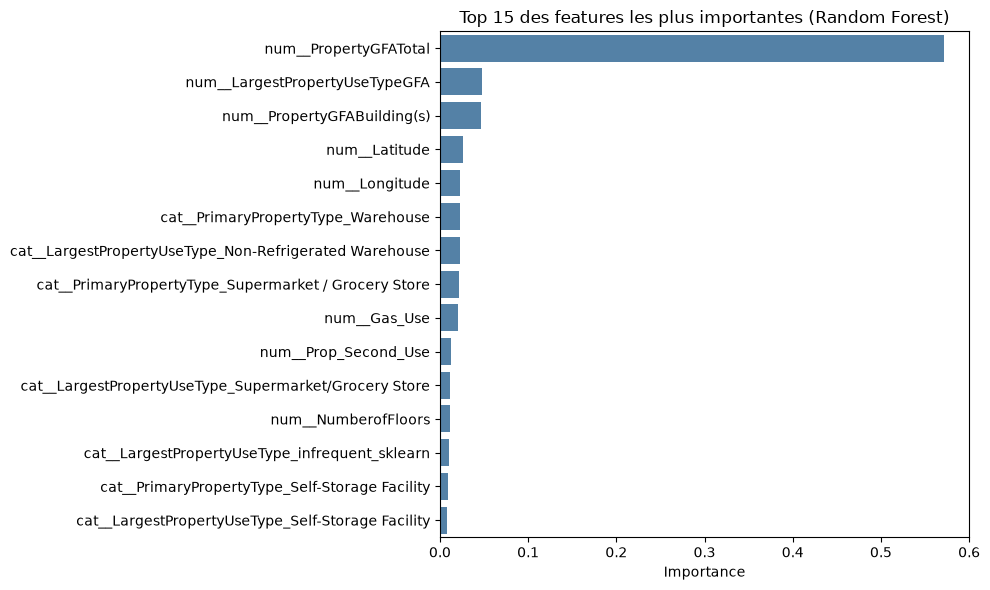

In [64]:
top_n = 15

plt.figure(figsize=(10, 6))
sns.barplot(data=importances.head(top_n), x="importance", y="feature", color="steelblue")
plt.title(f"Top {top_n} des features les plus importantes (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Lecture des feature importances**

- **La surface domine très largement** : les 3 colonnes de surface (`PropertyGFATotal` 0,572, `LargestPropertyUseTypeGFA` 0,048, `PropertyGFABuilding(s)` 0,047) portent à elles seules **67 % de l'importance totale**.

**Limites de cette méthode :**
- Le One-Hot **éclate chaque variable catégorielle** en plusieurs colonnes (une par catégorie). Le poids total d'une variable comme `PrimaryPropertyType` est donc dispersé et paraît plus faible qu'il ne l'est réellement.

Je regroupe à nouveau les catégories explosées par le one-hot

variable
PropertyGFATotal               0.572
PrimaryPropertyType            0.077
LargestPropertyUseType         0.069
LargestPropertyUseTypeGFA      0.048
PropertyGFABuilding(s)         0.047
Latitude                       0.027
Longitude                      0.023
decennie_construction          0.022
Gas_Use                        0.021
ZipCode                        0.016
Prop_Second_Use                0.012
SecondLargestPropertyUseType   0.012
NumberofFloors                 0.011
Neighborhood                   0.010
Prop_Third_Use                 0.007
CouncilDistrictCode            0.007
ThirdLargestPropertyUseType    0.006
BuildingType                   0.006
PropertyGFAParking             0.003
NumberofBuildings              0.002
Has_Second_Use                 0.001
Steam_Use                      0.001
Has_Third_Use                  0.001
Electricity_Use                0.000
Name: importance, dtype: float64


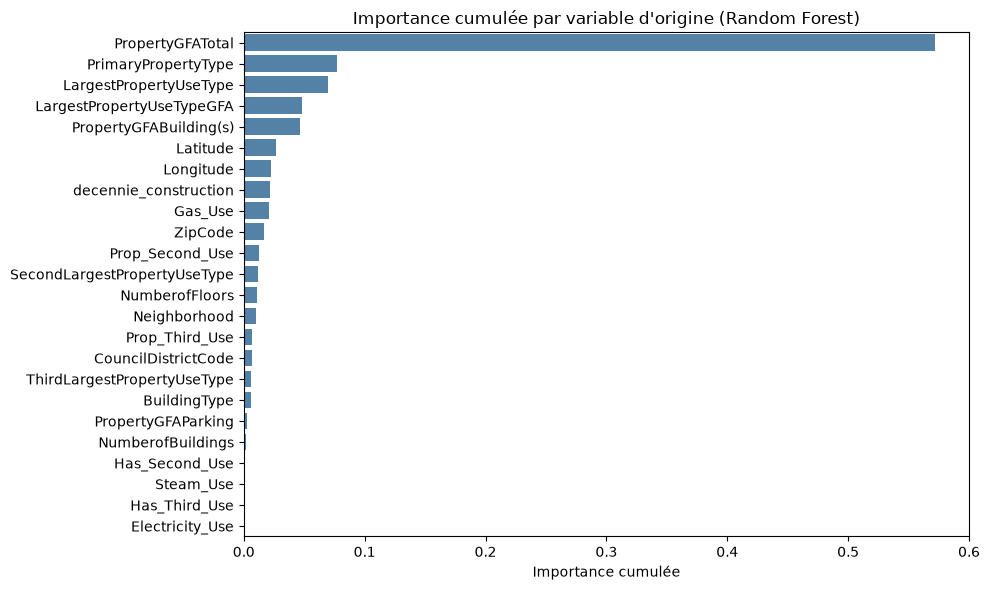

In [65]:
"""Feature importance regroupée par variable d'origine"""
# Le One-Hot a éclaté chaque variable catégorielle en plusieurs colonnes (une par catégorie).
# On retrouve pour chaque colonne sa variable d'origine, puis on additionne les importances.

def variable_origine(nom_colonne):
    """Retrouve la variable d'origine à partir du nom de colonne après transformation."""
    # Colonnes catégorielles : "cat__LargestPropertyUseType_Office" -> "LargestPropertyUseType"
    for col in colonnes_categorielles:
        if nom_colonne.startswith(f"cat__{col}_"):
            return col
    # Colonnes numériques : "num__PropertyGFATotal" -> "PropertyGFATotal"
    return nom_colonne.replace("num__", "")

importances["variable"] = importances["feature"].apply(variable_origine)

# Somme des importances par variable d'origine, de la plus importante à la moins importante
importances_par_variable = (
    importances.groupby("variable")["importance"]
    .sum()
    .sort_values(ascending=False)
)
print(importances_par_variable)

# Même graphique que précédemment, mais par variable d'origine
plt.figure(figsize=(10, 6))
sns.barplot(x=importances_par_variable.values, y=importances_par_variable.index, color="steelblue")
plt.title("Importance cumulée par variable d'origine (Random Forest)")
plt.xlabel("Importance cumulée")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Lecture des importances regroupées par variable d'origine**

Une fois les colonnes One-Hot réassemblées, le classement change : les variables catégorielles, dont le poids était dispersé, remontent nettement.

| Famille | Variables | Importance cumulée |
|---|---|---|
| **Taille** | surfaces (×3), étages, parking, nb de bâtiments | **≈ 68 %** |
| **Usage** | types d'usage (principal, 2e, 3e, BuildingType), proportions et indicateurs d'usages multiples | **≈ 19 %** |
| **Localisation** | latitude, longitude, code postal, quartier, district | **≈ 8 %** |
| **Temporalité** | `decennie_construction` | ≈ 2 % |
| **Sources d'énergie** | `Gas_Use`, `Steam_Use`, `Electricity_Use` | ≈ 2 % |

**Ce qu'on retient :**
- **La taille reste de loin le 1er facteur**, portée presque entièrement par `PropertyGFATotal` (0,572).
- **L'usage est le 2e facteur**, devant la localisation : `PrimaryPropertyType` (0,077) et `LargestPropertyUseType` (0,070) passent aux 2e et 3e places, alors qu'ils n'apparaissaient qu'éclatés en petites colonnes dans le classement précédent.
- **`decennie_construction` apparaît** (0,022, 8e), alors qu'elle était absente du top 15 : son poids était lui aussi dispersé entre les 12 décennies.
- **Certaines features apportent très peu** : `Electricity_Use` (0,000) est quasi constante (presque tous les bâtiments ont de l'électricité), et `Has_Second_Use` / `Has_Third_Use` (0,001) sont redondantes avec les proportions `Prop_Second_Use` / `Prop_Third_Use`, qui portent déjà l'information. Ce sont des candidates à la suppression pour simplifier le modèle.

**Conclusion :** la consommation d'un bâtiment s'explique d'abord par sa taille, ensuite par ce qu'on y fait, et dans une moindre mesure par l'endroit où il se trouve.

## 5.6 Traduction métier (kBtu, erreur relative)

In [66]:
"""On repasse en unité réelles hors du log"""
# Prédictions du modèle optimisé (encore en log)
y_pred_log = meilleur_rf.predict(X_test_prepared)

# Reconversion en vraies unités (kBtu)
y_pred_reel = np.exp(y_pred_log)

# Métriques finales, directement comparables aux vraies valeurs de consommation
mae_reel = mean_absolute_error(y_test, y_pred_reel)
rmse_reel = mean_squared_error(y_test, y_pred_reel) ** 0.5
r2_reel = r2_score(y_test, y_pred_reel)

print(f"MAE (kBtu) : {mae_reel:,.0f}")
print(f"RMSE (kBtu) : {rmse_reel:,.0f}")
print(f"R2 (échelle réelle) : {r2_reel:.3f}")

MAE (kBtu) : 2,845,087
RMSE (kBtu) : 6,441,369
R2 (échelle réelle) : 0.643


In [67]:
# Erreur relative par bâtiment, en % : chaque bâtiment compte "à égalité", contrairement au MAE
erreur_relative = (y_test - y_pred_reel).abs() / y_test * 100
print(f"Erreur relative médiane : {erreur_relative.median():.1f}%")
print(f"Erreur relative moyenne : {erreur_relative.mean():.1f}%")

# Part des bâtiments par tranche d'erreur
tranches = pd.cut(erreur_relative, [0, 10, 25, 50, 100, float("inf")], right=False)
print(tranches.value_counts(sort=False, normalize=True).round(3))

Erreur relative médiane : 37.0%
Erreur relative moyenne : 59.6%
SiteEnergyUse(kBtu)
[0.0, 10.0)     0.141
[10.0, 25.0)    0.247
[25.0, 50.0)    0.276
[50.0, 100.0)   0.214
[100.0, inf)    0.122
Name: proportion, dtype: float64


**Traduction des performances en langage métier**

**Pourquoi ne pas s'arrêter au MAE ?**
Une fois les prédictions reconverties en kBtu, le MAE vaut **2,8 M kBtu**, soit plus que la consommation médiane d'un bâtiment (≈ 2,7 M). Ce chiffre est trompeur : une erreur de 20 % sur un très gros bâtiment pèse des millions de kBtu, alors que la même erreur sur un petit bâtiment pèse très peu. Le MAE, et encore plus le RMSE (6,4 M), sont donc **dominés par quelques très gros bâtiments**. Pour la même raison, le R² passe de 0,73 (en log) à **0,644** en échelle réelle.

**L'erreur relative, plus parlante**
En mesurant l'écart en % de la consommation réelle, chaque bâtiment compte à égalité, quelle que soit sa taille :
- **Erreur médiane de 37 %** : pour un bâtiment typique, l'estimation s'écarte d'environ un tiers de sa consommation réelle.
- **2 bâtiments sur 3** (66 %) sont estimés à moins de 50 % près, et **4 sur 10** (39 %) à moins de 25 %.
- **1 bâtiment sur 8** (12,5 %) est très mal estimé (erreur > 100 %). Ces cas tirent la moyenne vers le haut (**59,5 %** contre 37 % pour la médiane).

**Conclusion :** le modèle donne un **bon ordre de grandeur** de la consommation d'un bâtiment à partir de ses seules caractéristiques structurelles. Il est utile pour **prioriser** les bâtiments à relever en premier (repérer les gros consommateurs probables), mais pas encore assez précis pour **remplacer** une mesure réelle.